# Análisis Filogenético PGLS: Predictibilidad del Modelo de Clasificación de Aves

Este notebook evalúa si la predictibilidad del modelo de clasificación de aves (F1-score) se explica por filogenia, y qué variables de AVONET explican mejor el rendimiento después de controlar por efectos filogenéticos.

## Contenido
1. Configuración y Carga de Datos
2. Reconciliación de Nombres de Especies
3. Preparación de Datos
4. Señal Filogenética (Lambda de Pagel, K de Blomberg)
5. Análisis PGLS
6. Importancia de Variables
7. Visualizaciones
8. Conclusiones

## 1. Configuración y Carga de Datos

In [1]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.linalg import inv, cholesky
from scipy.special import logit, expit  # Para transformación logit
import statsmodels.api as sm
from statsmodels.regression.linear_model import GLS, OLS
import warnings
warnings.filterwarnings('ignore')

# Árboles filogenéticos - usar ete3 que es más robusto para NEXUS
try:
    from ete3 import Tree as EteTree
    USE_ETE3 = True
    print("Usando ete3 para árboles filogenéticos")
except ImportError:
    print("ete3 no disponible, usando Bio.Phylo")
    USE_ETE3 = False
    from io import StringIO
    from Bio import Phylo

plt.style.use('seaborn-v0_8-whitegrid')
print("Librerías cargadas correctamente")

Usando ete3 para árboles filogenéticos
Librerías cargadas correctamente


In [2]:
# Cargar datos de rendimiento del modelo
performance_df = pd.read_csv('../src/data/reporte_resnet.csv')
print(f"Datos de rendimiento cargados: {performance_df.shape[0]} especies")
print(f"\nColumnas: {list(performance_df.columns)}")
print(f"\nEstadísticas de F1-score:")
print(performance_df['f1-score'].describe())

Datos de rendimiento cargados: 667 especies

Columnas: ['species', 'precision', 'recall', 'f1-score', 'support']

Estadísticas de F1-score:
count    667.000000
mean       0.858036
std        0.064397
min        0.480000
25%        0.820000
50%        0.870000
75%        0.900000
max        1.000000
Name: f1-score, dtype: float64


In [3]:
# Cargar árbol filogenético (formato NEXUS)
# El archivo NEXUS usa IDs numéricos con un bloque TRANSLATE, así que lo parseamos manualmente

import re

def load_nexus_tree_with_translate(filepath):
    """
    Carga un árbol NEXUS que usa bloque TRANSLATE con IDs numéricos.
    Retorna el árbol Newick con nombres de especies reemplazados.
    """
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extraer bloque TRANSLATE
    translate_match = re.search(r'TRANSLATE\s+(.*?);', content, re.DOTALL | re.IGNORECASE)
    if not translate_match:
        raise ValueError("No se encontró bloque TRANSLATE")
    
    translate_block = translate_match.group(1)
    
    # Parsear el mapeo ID -> nombre
    id_to_name = {}
    for line in translate_block.strip().split('\n'):
        line = line.strip().rstrip(',')
        if line:
            parts = line.split()
            if len(parts) >= 2:
                id_num = parts[0]
                name = parts[1].rstrip(',')
                id_to_name[id_num] = name
    
    print(f"TRANSLATE block: {len(id_to_name)} especies mapeadas")
    
    # Extraer el árbol Newick
    # Patrón: TREE * nombre = [&R] (newick);
    tree_match = re.search(r'TREE\s+\*?\s*\w+\s*=\s*\[&R\]\s*(\([^;]+;)', content, re.IGNORECASE)
    if not tree_match:
        # Intentar sin [&R]
        tree_match = re.search(r'TREE\s+\*?\s*\w+\s*=\s*(\([^;]+;)', content, re.IGNORECASE)
    
    if not tree_match:
        raise ValueError("No se encontró árbol en el archivo NEXUS")
    
    newick_str = tree_match.group(1)
    
    # Reemplazar IDs numéricos con nombres de especies
    # Usar regex para reemplazar números que son IDs de taxa (precedidos por ( o , y seguidos por :)
    def replace_id(match):
        id_num = match.group(1)
        separator = match.group(2)
        if id_num in id_to_name:
            return id_to_name[id_num] + separator
        return match.group(0)
    
    # Patrón: número seguido de : , o )
    newick_with_names = re.sub(r'(\d+)([:,\)])', replace_id, newick_str)
    
    return newick_with_names, set(id_to_name.values())

# Cargar el árbol
nexus_path = './data/Stage2_MayrAll_Ericson_set10_decisive.nex'
newick_str, tree_species = load_nexus_tree_with_translate(nexus_path)
print(f"Árbol Newick cargado ({len(newick_str)} caracteres)")
print(f"Total de especies en el árbol: {len(tree_species)}")

# Parsear con ete3 o BioPython
if USE_ETE3:
    tree = EteTree(newick_str, format=1)
    loaded_species = set([leaf.name for leaf in tree.iter_leaves()])
    print(f"Árbol parseado con ete3: {len(loaded_species)} especies")
elif USE_BIOPYTHON:
    tree = Phylo.read(StringIO(newick_str), 'newick')
    loaded_species = set([tip.name for tip in tree.get_terminals()])
    print(f"Árbol parseado con BioPython: {len(loaded_species)} especies")
else:
    raise ImportError("Se requiere ete3 o BioPython para cargar el árbol")

# Mostrar algunas especies para verificar
print(f"\nPrimeras 10 especies en el árbol:")
for sp in list(tree_species)[:10]:
    print(f"  - {sp}")

TRANSLATE block: 9993 especies mapeadas
Árbol Newick cargado (464293 caracteres)
Total de especies en el árbol: 9992
Árbol parseado con ete3: 9992 especies

Primeras 10 especies en el árbol:
  - Anser_cygnoides
  - Calypte_anna
  - Sturnus_unicolor
  - Dysithamnus_stictothorax
  - Aratinga_chloroptera
  - Trogon_melanocephalus
  - Ptilogonys_cinereus
  - Leptasthenura_platensis
  - Pycnonotus_jocosus
  - Cacatua_alba


In [4]:
# Cargar datos AVONET (hoja AVONET3_BirdTree para compatibilidad con árbol BirdTree)
avonet_df = pd.read_excel('../src/data/AVONET.xlsx', sheet_name='AVONET3_BirdTree')
print(f"AVONET cargado: {avonet_df.shape[0]} especies")
print(f"\nColumnas disponibles:")
print(list(avonet_df.columns))

AVONET cargado: 9993 especies

Columnas disponibles:
['Species3', 'Family3', 'Order3', 'Total.individuals', 'Female', 'Male', 'Unknown', 'Complete.measures', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Kipps.Distance', 'Secondary1', 'Hand-Wing.Index', 'Tail.Length', 'Mass', 'Mass.Source', 'Mass.Refs.Other', 'Inference', 'Traits.inferred', 'Reference.species', 'Habitat', 'Habitat.Density', 'Migration', 'Trophic.Level', 'Trophic.Niche', 'Primary.Lifestyle', 'Min.Latitude', 'Max.Latitude', 'Centroid.Latitude', 'Centroid.Longitude', 'Range.Size', 'Species.Status']


## 2. Reconciliación de Nombres de Especies

In [5]:
# Diccionario de sinonimias basado en utils.py
SYNONYMS_AVONET = {
    "Tangara_vitriolina": "Stilpnia_vitriolina",
    "Tangara_nigrocincta": "Stilpnia_nigrocincta",
    "Spodiornis_rusticus": "Haplospiza_rustica",
    "Vireo_pallens": "Vireo_approximans",
    "Tangara_palmarum": "Thraupis_palmarum",
    "Tangara_glaucocolpa": "Thraupis_glaucocolpa",
    "Tangara_episcopus": "Thraupis_episcopus",
    "Maschalethraupis_surinama": "Tachyphonus_surinamus",
    "Chrysocorypha_delatrii": "Tachyphonus_delatrii",
    "Tangara_larvata": "Stilpnia_larvata",
    "Tangara_heinei": "Stilpnia_heinei",
    "Tangara_cyanoptera": "Stilpnia_cyanoptera",
    "Tangara_cyanicollis": "Stilpnia_cyanicollis",
    "Tangara_cayana": "Stilpnia_cayana",
    "Pyriglena_leuconota": "Pyriglena_maura",
    "Pseudocolaptes_boissonneauii": "Pseudocolaptes_boissonneautii",
    "Polioptila_guianensis": "Polioptila_facilis",
    "Islerothraupis_cristata": "Loriotus_cristatus",
    "Grallaria_fenwickorum": "Grallaria_urraoensis",
    "Islerothraupis_luctuosa": "Loriotus_luctuosus",
    "Tangara_ruficervix": "Chalcothraupis_ruficervix",
    "Euphonia_cyanocephala": "Chlorophonia_cyanocephala",
    "Thripophaga_gutturata": "Cranioleuca_gutturata",
    "Philydor_erythropterum": "Dendroma_erythroptera",
    "Philydor_rufum": "Dendroma_rufa",
    "Tangara_guttata": "Ixothraupis_guttata",
    "Tangara_punctata": "Ixothraupis_punctata",
    "Tangara_rufigula": "Ixothraupis_rufigula",
    "Tangara_varia": "Ixothraupis_varia",
    "Tangara_xanthogastra": "Ixothraupis_xanthogastra",
    "Chloropipo_flavicapilla": "Xenopipo_flavicapilla"
}

SYNONYMS_PERFORMANCE = {
    "Uromyias_agilis": "Anairetes_agilis",
    "Xenops_rutilans": "Xenops_rutilus",
    "Chloropipo_flavicapilla": "Xenopipo_flavicapilla",
    "Premnornis_guttuliger": "Premnornis_guttuligera"
}

# Sinonimias inversas para el árbol (de nombre actual a nombre en el árbol)
# El árbol usa nomenclatura BirdTree, algunas especies tienen nombres diferentes
SYNONYMS_TO_TREE = {v: k for k, v in SYNONYMS_AVONET.items()}

In [6]:
# Estandarizar nombres: "Genus species" → "Genus_species"
performance_df['species'] = performance_df['species'].str.replace(' ', '_')

# Aplicar sinonimias a datos de rendimiento
performance_df['species_std'] = performance_df['species'].replace(SYNONYMS_PERFORMANCE)

# Preparar AVONET
avonet_df['Species3'] = avonet_df['Species3'].str.replace(' ', '_')
avonet_df['species_std'] = avonet_df['Species3'].replace(SYNONYMS_AVONET)

print(f"Especies en rendimiento: {performance_df['species_std'].nunique()}")
print(f"Especies en AVONET: {avonet_df['species_std'].nunique()}")
print(f"Especies en árbol: {len(tree_species)}")

Especies en rendimiento: 667
Especies en AVONET: 9993
Especies en árbol: 9992


In [7]:
# Crear mapeo de nombres de rendimiento a nombres del árbol
performance_species = set(performance_df['species_std'])
avonet_species = set(avonet_df['species_std'])

# Encontrar especies en común entre los tres datasets
# Primero entre rendimiento y AVONET
perf_avonet_common = performance_species & avonet_species
print(f"Especies en común (rendimiento ∩ AVONET): {len(perf_avonet_common)}")

# Ahora encontrar cuáles están en el árbol
# El árbol puede usar nombres diferentes, necesitamos buscar matches
species_in_tree = set()
species_tree_mapping = {}  # mapeo: nombre_std -> nombre_arbol

for sp in perf_avonet_common:
    if sp in tree_species:
        species_in_tree.add(sp)
        species_tree_mapping[sp] = sp
    # Buscar si hay un sinónimo en el árbol
    elif sp in SYNONYMS_TO_TREE and SYNONYMS_TO_TREE[sp] in tree_species:
        species_in_tree.add(sp)
        species_tree_mapping[sp] = SYNONYMS_TO_TREE[sp]

print(f"Especies en común (tres datasets): {len(species_in_tree)}")

Especies en común (rendimiento ∩ AVONET): 586
Especies en común (tres datasets): 586


In [8]:
# Mostrar algunas especies que no se encontraron para diagnóstico
not_in_tree = perf_avonet_common - species_in_tree
print(f"\nEspecies no encontradas en árbol: {len(not_in_tree)}")
if len(not_in_tree) > 0:
    print("\nPrimeras 20 especies no encontradas:")
    for sp in list(not_in_tree)[:20]:
        print(f"  - {sp}")


Especies no encontradas en árbol: 0


## 3. Preparación de Datos

In [9]:
# Filtrar datasets a especies en común
perf_filtered = performance_df[performance_df['species_std'].isin(species_in_tree)].copy()
avonet_filtered = avonet_df[avonet_df['species_std'].isin(species_in_tree)].copy()

# Fusionar datasets
merged_df = pd.merge(
    perf_filtered[['species_std', 'f1-score', 'precision', 'recall', 'support']],
    avonet_filtered,
    on='species_std',
    how='inner'
)

# Agregar nombre del árbol
merged_df['tree_name'] = merged_df['species_std'].map(species_tree_mapping)

print(f"Dataset fusionado: {merged_df.shape[0]} especies")
merged_df.head()

Dataset fusionado: 586 especies


,species_std,f1-score,precision,recall,support,Species3,Family3,Order3,Total.individuals,Female,...,Trophic.Level,Trophic.Niche,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size,Species.Status,tree_name
0,Acropternis_orthonyx,0.95,0.97,0.92,75,Acropternis_orthonyx,Rhinocryptidae,Passeriformes,9,2,...,Carnivore,Invertivore,Insessorial,-5.46,9.74,1.60,-76.740209,112912.00,Extant,Acropternis_orthonyx
1,Amblycercus_holosericeus,0.79,0.76,0.81,27,Amblycercus_holosericeus,Icteridae,Passeriformes,27,4,...,Carnivore,Invertivore,Insessorial,-18.35,23.75,9.78,-84.393677,1152587.02,Extant,Amblycercus_holosericeus
2,Ammodramus_aurifrons,0.84,0.83,0.84,58,Ammodramus_aurifrons,Emberizidae,Passeriformes,9,4,...,Herbivore,Granivore,Terrestrial,-17.92,10.18,-3.98,-66.528495,3867543.93,Extant,Ammodramus_aurifrons
3,Ammodramus_humeralis,0.84,0.86,0.82,74,Ammodramus_humeralis,Emberizidae,Passeriformes,12,4,...,Herbivore,Granivore,Terrestrial,-41.17,12.46,-16.41,-54.836068,9115378.43,Extant,Ammodramus_humeralis
4,Ammodramus_savannarum,0.86,0.84,0.88,75,Ammodramus_savannarum,Emberizidae,Passeriformes,6,3,...,Omnivore,Invertivore,Generalist,3.31,51.58,40.30,-94.603997,5240941.22,Extant,Ammodramus_savannarum


### Transformación Logit y Análisis de Support

**Mejoras metodológicas:**
1. **Transformación logit**: El F1-score está acotado en [0,1], violando supuestos de normalidad. La transformación logit mapea (0,1) → (-∞, +∞)
2. **Support como covariable**: El número de muestras por especie afecta la variabilidad del F1-score

Comparación F1 original vs logit(F1):

F1 original:
count    586.000000
mean       0.857082
std        0.064985
min        0.480000
25%        0.820000
50%        0.870000
75%        0.900000
max        1.000000
Name: f1-score, dtype: float64

logit(F1):
count    586.000000
mean       1.900883
std        0.594413
min       -0.080043
25%        1.516347
50%        1.900959
75%        2.197225
max        6.906755
Name: f1_logit, dtype: float64


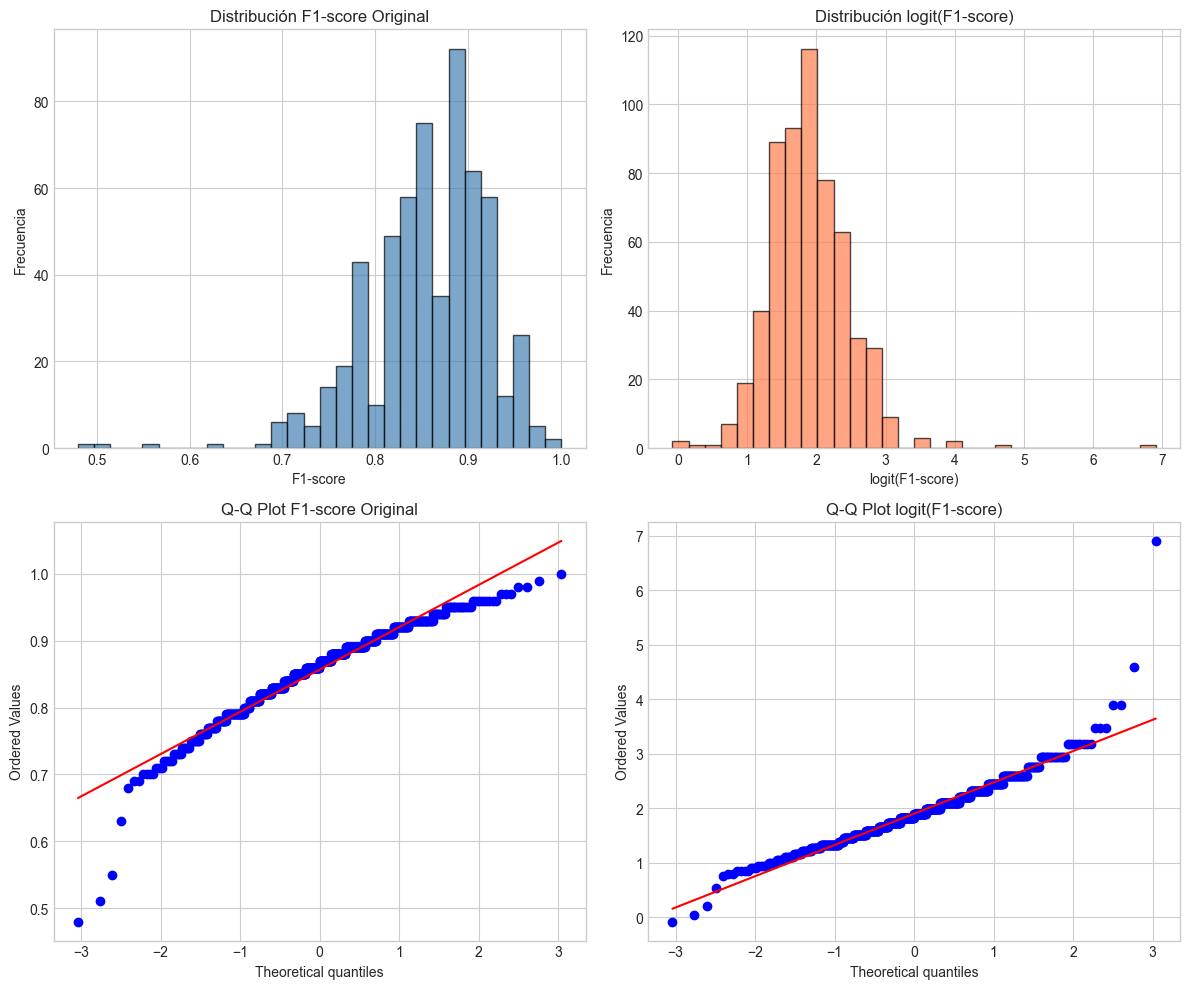


Tests de Normalidad (Shapiro-Wilk):
  F1 original: p = 0.000000
  logit(F1):   p = 0.000001


In [10]:
# Transformación logit del F1-score
def safe_logit(p, eps=0.001):
    """Transformación logit con corrección para evitar infinitos."""
    p_adj = np.clip(p, eps, 1 - eps)
    return logit(p_adj)

# Aplicar transformación
merged_df['f1_logit'] = safe_logit(merged_df['f1-score'].values)

print("Comparación F1 original vs logit(F1):")
print(f"\nF1 original:")
print(merged_df['f1-score'].describe())
print(f"\nlogit(F1):")
print(merged_df['f1_logit'].describe())

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribución F1 original
axes[0, 0].hist(merged_df['f1-score'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('F1-score')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución F1-score Original')

# Distribución logit(F1)
axes[0, 1].hist(merged_df['f1_logit'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('logit(F1-score)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución logit(F1-score)')

# Q-Q plots
stats.probplot(merged_df['f1-score'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot F1-score Original')

stats.probplot(merged_df['f1_logit'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot logit(F1-score)')

plt.tight_layout()
plt.savefig('../fig/pgls_logit_transformation.png', dpi=150, bbox_inches='tight')
plt.show()

# Tests de normalidad
print("\nTests de Normalidad (Shapiro-Wilk):")
_, p_orig = stats.shapiro(merged_df['f1-score'].sample(min(500, len(merged_df)), random_state=42))
_, p_logit = stats.shapiro(merged_df['f1_logit'].sample(min(500, len(merged_df)), random_state=42))
print(f"  F1 original: p = {p_orig:.6f}")
print(f"  logit(F1):   p = {p_logit:.6f}")

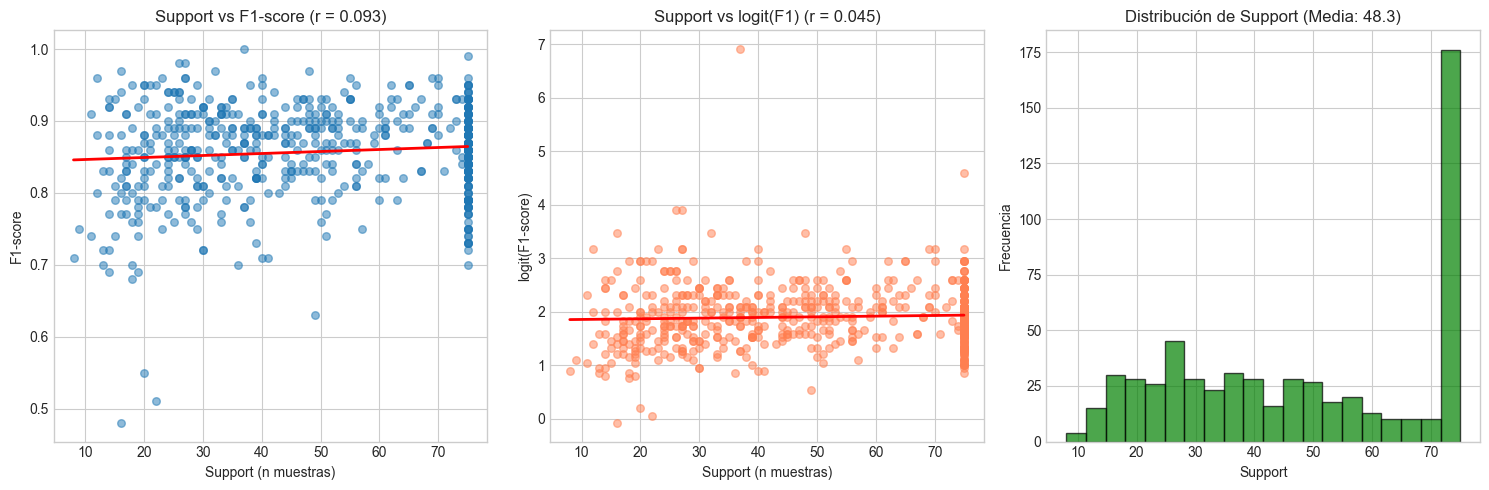


Correlación support-F1: r = 0.0927
Correlación support-logit(F1): r = 0.0450


In [11]:
# Análisis del efecto del support
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Support vs F1
axes[0].scatter(merged_df['support'], merged_df['f1-score'], alpha=0.5, s=30)
z = np.polyfit(merged_df['support'], merged_df['f1-score'], 1)
p = np.poly1d(z)
axes[0].plot(merged_df['support'].sort_values(), p(merged_df['support'].sort_values()), color='red', linewidth=2)
corr_support = merged_df['support'].corr(merged_df['f1-score'])
axes[0].set_xlabel('Support (n muestras)')
axes[0].set_ylabel('F1-score')
axes[0].set_title(f'Support vs F1-score (r = {corr_support:.3f})')

# Support vs logit(F1)
axes[1].scatter(merged_df['support'], merged_df['f1_logit'], alpha=0.5, s=30, color='coral')
z2 = np.polyfit(merged_df['support'], merged_df['f1_logit'], 1)
p2 = np.poly1d(z2)
axes[1].plot(merged_df['support'].sort_values(), p2(merged_df['support'].sort_values()), color='red', linewidth=2)
corr_support_logit = merged_df['support'].corr(merged_df['f1_logit'])
axes[1].set_xlabel('Support (n muestras)')
axes[1].set_ylabel('logit(F1-score)')
axes[1].set_title(f'Support vs logit(F1) (r = {corr_support_logit:.3f})')

# Distribución de support
axes[2].hist(merged_df['support'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('Support')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title(f'Distribución de Support (Media: {merged_df["support"].mean():.1f})')

plt.tight_layout()
plt.savefig('../fig/pgls_support_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCorrelación support-F1: r = {corr_support:.4f}")
print(f"Correlación support-logit(F1): r = {corr_support_logit:.4f}")

# Preparar variables para modelos
merged_df['log_support'] = np.log10(merged_df['support'])

In [12]:
# Seleccionar variables de interés de AVONET
# Variables morfológicas
morpho_vars = ['Mass', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 
               'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Tail.Length', 'Hand-Wing.Index']

# Variables ecológicas (categóricas - necesitan codificación)
eco_vars_cat = ['Habitat', 'Trophic.Level', 'Trophic.Niche', 'Primary.Lifestyle']

# Variables geográficas
geo_vars = ['Range.Size', 'Centroid.Latitude', 'Centroid.Longitude']

# Verificar disponibilidad de variables
available_cols = merged_df.columns.tolist()
morpho_available = [v for v in morpho_vars if v in available_cols]
eco_available = [v for v in eco_vars_cat if v in available_cols]
geo_available = [v for v in geo_vars if v in available_cols]

print(f"Variables morfológicas disponibles: {morpho_available}")
print(f"Variables ecológicas disponibles: {eco_available}")
print(f"Variables geográficas disponibles: {geo_available}")

Variables morfológicas disponibles: ['Mass', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Tail.Length', 'Hand-Wing.Index']
Variables ecológicas disponibles: ['Habitat', 'Trophic.Level', 'Trophic.Niche', 'Primary.Lifestyle']
Variables geográficas disponibles: ['Range.Size', 'Centroid.Latitude', 'Centroid.Longitude']


In [13]:
# Podar árbol a especies coincidentes
tree_names_to_keep = set(merged_df['tree_name'].tolist())

if USE_ETE3:
    # Crear copia del árbol y podar
    pruned_tree = tree.copy()
    
    # Eliminar hojas que no están en nuestro dataset
    leaves_to_remove = [leaf for leaf in pruned_tree.iter_leaves() 
                        if leaf.name not in tree_names_to_keep]
    for leaf in leaves_to_remove:
        leaf.delete()
    
    # Verificar
    pruned_species = [leaf.name for leaf in pruned_tree.iter_leaves()]
    print(f"Árbol podado: {len(pruned_species)} especies")
    
elif USE_BIOPYTHON:
    # BioPython approach
    from Bio.Phylo.BaseTree import Tree as BioTree
    pruned_tree = Phylo.read(StringIO(newick_str), 'newick')
    
    # Filtrar terminales
    terminals_to_keep = [t for t in pruned_tree.get_terminals() 
                         if t.name in tree_names_to_keep]
    
    # Esto es más complejo con BioPython, usemos ete3 si está disponible
    pruned_species = [t.name for t in terminals_to_keep]
    print(f"Árbol podado: {len(pruned_species)} especies")

# Filtrar merged_df a especies que están en el árbol podado
merged_df = merged_df[merged_df['tree_name'].isin(pruned_species)]

# Asegurar que el orden de las especies en merged_df coincida con el árbol
# Reordenar merged_df según el orden del árbol
species_order = {sp: i for i, sp in enumerate(pruned_species)}
merged_df['tree_order'] = merged_df['tree_name'].map(species_order)
merged_df = merged_df.sort_values('tree_order').drop('tree_order', axis=1).reset_index(drop=True)

print(f"Dataset ordenado según árbol: {merged_df.shape[0]} especies")

Árbol podado: 586 especies
Dataset ordenado según árbol: 586 especies


In [14]:
def compute_vcv_matrix_ete3(tree, species_list):
    """
    Calcula la matriz de varianza-covarianza filogenética usando ete3.
    VCV[i,j] = longitud de rama compartida entre especies i y j desde la raíz.
    """
    n = len(species_list)
    vcv = np.zeros((n, n))
    
    # Crear mapeo de nombres a índices
    species_idx = {sp: i for i, sp in enumerate(species_list)}
    
    # Obtener nodos hoja por nombre
    leaf_nodes = {leaf.name: leaf for leaf in tree.iter_leaves() if leaf.name in species_idx}
    
    # Calcular distancia desde raíz a cada nodo
    for i, sp_i in enumerate(species_list):
        if sp_i not in leaf_nodes:
            continue
        node_i = leaf_nodes[sp_i]
        
        for j, sp_j in enumerate(species_list):
            if j < i:
                vcv[i, j] = vcv[j, i]
                continue
            if sp_j not in leaf_nodes:
                continue
            node_j = leaf_nodes[sp_j]
            
            # Encontrar ancestro común más reciente (MRCA)
            mrca = tree.get_common_ancestor(node_i, node_j)
            
            # Covarianza = distancia desde raíz hasta MRCA
            # Calculamos la distancia desde MRCA hasta la raíz
            shared_length = tree.get_distance(tree, mrca)
            vcv[i, j] = shared_length
            vcv[j, i] = shared_length
    
    return vcv

def compute_vcv_matrix_simple(tree, species_list):
    """
    Versión simplificada: usa distancias patrísticas para estimar VCV.
    VCV[i,j] = (dist_to_root_i + dist_to_root_j - patristic_dist_ij) / 2
    """
    n = len(species_list)
    vcv = np.zeros((n, n))
    
    # Mapeo de nombres a nodos
    species_idx = {sp: i for i, sp in enumerate(species_list)}
    
    if USE_ETE3:
        leaf_nodes = {leaf.name: leaf for leaf in tree.iter_leaves() if leaf.name in species_idx}
        
        # Calcular distancias a la raíz para cada especie
        dist_to_root = {}
        for sp in species_list:
            if sp in leaf_nodes:
                dist_to_root[sp] = tree.get_distance(leaf_nodes[sp])
            else:
                dist_to_root[sp] = 0
        
        # Calcular matriz VCV
        for i, sp_i in enumerate(species_list):
            for j, sp_j in enumerate(species_list):
                if j < i:
                    vcv[i, j] = vcv[j, i]
                    continue
                
                if sp_i in leaf_nodes and sp_j in leaf_nodes:
                    # Distancia patrística
                    patr_dist = tree.get_distance(leaf_nodes[sp_i], leaf_nodes[sp_j])
                    # VCV = (d_i + d_j - d_ij) / 2 = distancia compartida desde raíz
                    vcv[i, j] = (dist_to_root[sp_i] + dist_to_root[sp_j] - patr_dist) / 2
                else:
                    vcv[i, j] = 0
                vcv[j, i] = vcv[i, j]
    
    return vcv

# Usar la lista de especies del merged_df ordenado
species_list = merged_df['tree_name'].tolist()

print("Calculando matriz VCV (esto puede tomar unos minutos)...")
if USE_ETE3:
    vcv_matrix = compute_vcv_matrix_simple(pruned_tree, species_list)
else:
    print("Nota: Usando método simplificado sin ete3")
    # Crear matriz identidad como fallback
    vcv_matrix = np.eye(len(species_list))

vcv_taxa = species_list
vcv_taxa_idx = {sp: idx for idx, sp in enumerate(vcv_taxa)}

print(f"Matriz VCV calculada: {vcv_matrix.shape}")
print(f"Diagonal (varianzas): min={vcv_matrix.diagonal().min():.4f}, max={vcv_matrix.diagonal().max():.4f}")

# Verificar que la matriz es válida
if vcv_matrix.diagonal().max() == 0:
    print("\nAdvertencia: La matriz VCV tiene ceros en la diagonal.")
    print("    Usando matriz normalizada...")
    # Normalizar por la distancia máxima a la raíz
    max_depth = vcv_matrix.max()
    if max_depth > 0:
        vcv_matrix = vcv_matrix / max_depth

Calculando matriz VCV (esto puede tomar unos minutos)...
Matriz VCV calculada: (586, 586)
Diagonal (varianzas): min=6.0909, max=73.4783


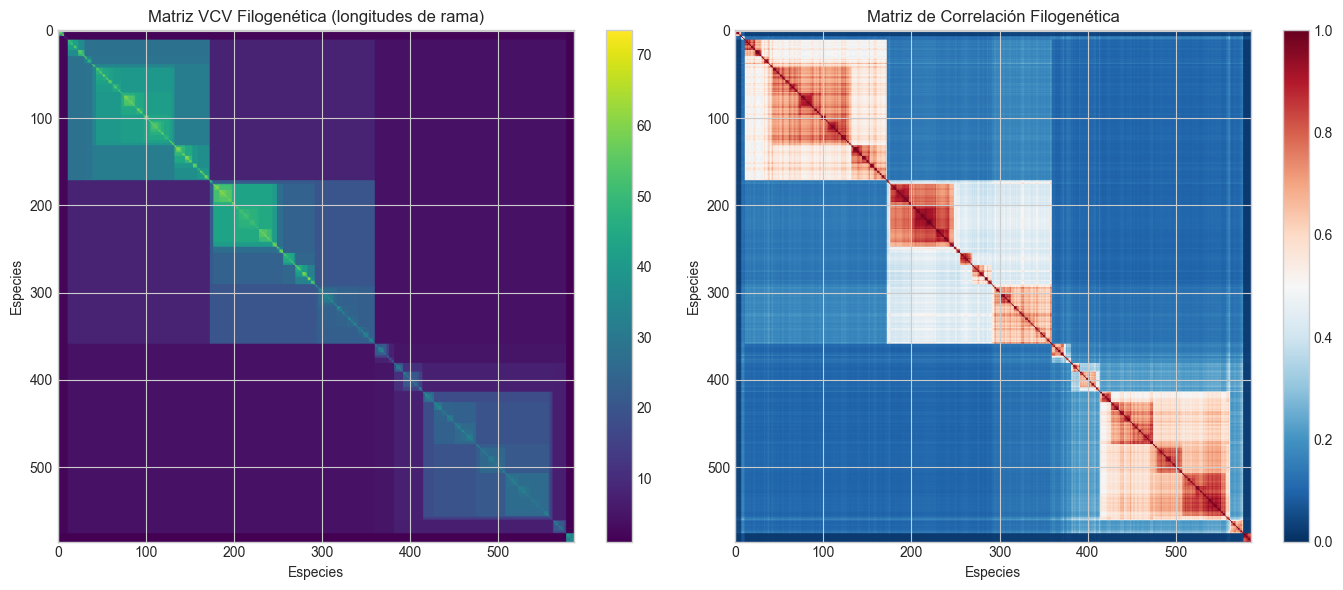

In [15]:
# Normalizar VCV para que la diagonal sea 1 (correlaciones)
vcv_diag = np.sqrt(np.diag(vcv_matrix))
vcv_corr = vcv_matrix / np.outer(vcv_diag, vcv_diag)

# Visualizar matriz VCV
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz original
im1 = axes[0].imshow(vcv_matrix, cmap='viridis', aspect='auto')
axes[0].set_title('Matriz VCV Filogenética (longitudes de rama)')
axes[0].set_xlabel('Especies')
axes[0].set_ylabel('Especies')
plt.colorbar(im1, ax=axes[0])

# Matriz normalizada
im2 = axes[1].imshow(vcv_corr, cmap='RdBu_r', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Matriz de Correlación Filogenética')
axes[1].set_xlabel('Especies')
axes[1].set_ylabel('Especies')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig('../fig/pgls_vcv_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Señal Filogenética

In [16]:
def pagel_lambda_likelihood(lam, y, vcv):
    """
    Calcula el log-likelihood negativo para un valor dado de lambda de Pagel.
    V_lambda = lambda * VCV + (1 - lambda) * I
    """
    n = len(y)
    I = np.eye(n)
    
    # Transformar matriz VCV con lambda
    V_lambda = lam * vcv + (1 - lam) * I
    
    try:
        # Calcular inversa y determinante
        V_inv = inv(V_lambda)
        sign, logdet = np.linalg.slogdet(V_lambda)
        
        if sign <= 0:
            return np.inf
        
        # ML estimate de la media
        ones = np.ones(n)
        mu = (ones @ V_inv @ y) / (ones @ V_inv @ ones)
        
        # Residuos
        resid = y - mu
        
        # ML estimate de sigma^2
        sigma2 = (resid @ V_inv @ resid) / n
        
        # Log-likelihood
        ll = -0.5 * (n * np.log(2 * np.pi) + n * np.log(sigma2) + logdet + n)
        
        return -ll  # Negativo para minimizar
    except:
        return np.inf

def estimate_pagel_lambda(y, vcv):
    """
    Estima lambda de Pagel por máxima verosimilitud.
    """
    # Normalizar VCV
    vcv_norm = vcv / vcv.max()
    
    # Optimizar lambda
    result = minimize_scalar(
        lambda lam: pagel_lambda_likelihood(lam, y, vcv_norm),
        bounds=(0, 1),
        method='bounded'
    )
    
    lambda_est = result.x
    ll_lambda = -result.fun
    
    # Log-likelihood bajo lambda=0 (sin señal filogenética)
    ll_0 = -pagel_lambda_likelihood(0, y, vcv_norm)
    
    # Log-likelihood bajo lambda=1 (movimiento Browniano)
    ll_1 = -pagel_lambda_likelihood(1, y, vcv_norm)
    
    # Likelihood ratio test vs lambda=0
    lr_stat = 2 * (ll_lambda - ll_0)
    p_value = 1 - stats.chi2.cdf(lr_stat, df=1) if lr_stat > 0 else 1.0
    
    return {
        'lambda': lambda_est,
        'loglik': ll_lambda,
        'loglik_0': ll_0,
        'loglik_1': ll_1,
        'LR_stat': lr_stat,
        'p_value': p_value
    }

In [17]:
def blomberg_k(y, vcv):
    """
    Calcula K de Blomberg.
    K = (MSE_obs / MSE_BM)
    donde MSE_obs es la varianza observada de los contrastes
    y MSE_BM es la esperada bajo movimiento Browniano.
    """
    n = len(y)
    
    # Normalizar VCV
    vcv_norm = vcv / vcv.max()
    
    try:
        V_inv = inv(vcv_norm)
    except:
        return {'K': np.nan, 'p_value': np.nan}
    
    ones = np.ones(n)
    
    # Media filogenética
    a = (ones @ V_inv @ y) / (ones @ V_inv @ ones)
    
    # MSE observado (varianza de los datos)
    mse_obs = np.var(y, ddof=0)
    
    # MSE esperado bajo BM
    resid = y - a
    mse_bm = (resid @ V_inv @ resid) / n
    
    # K de Blomberg
    # K = (MSE_obs/MSE_0) / (MSE_obs/MSE_BM_exp)
    # Simplificado: comparamos la varianza observada con la esperada bajo BM
    
    # Cálculo simplificado de K
    C = vcv_norm
    C_bar = C.mean()
    
    # Numerador: suma de cuadrados observada
    y_bar = y.mean()
    ss_obs = np.sum((y - y_bar)**2)
    
    # Denominador: suma de cuadrados esperada bajo BM
    # MSE esperado = traza(C) - n*C_bar
    mse_exp = (np.trace(C) - n * C_bar) / (n - 1)
    
    K = (mse_obs / n) / mse_exp if mse_exp > 0 else np.nan
    
    return {
        'K': K,
        'MSE_obs': mse_obs,
        'MSE_exp': mse_exp
    }

In [18]:
# Extraer F1-scores en el orden correcto
f1_scores = merged_df['f1-score'].values

# Verificar que tenemos suficientes datos
print(f"Número de especies con F1-scores: {len(f1_scores)}")

if len(f1_scores) < 10:
    print("⚠️  Muy pocas especies para el análisis. Verificar reconciliación de nombres.")
else:
    print("Calculando señal filogenética...")
    print("="*50)
    
    # Lambda de Pagel
    lambda_result = estimate_pagel_lambda(f1_scores, vcv_matrix)
    print(f"\nLAMBDA DE PAGEL")
    print(f"  λ estimado: {lambda_result['lambda']:.4f}")
    print(f"  Log-likelihood (λ óptimo): {lambda_result['loglik']:.2f}")
    print(f"  Log-likelihood (λ=0): {lambda_result['loglik_0']:.2f}")
    print(f"  Log-likelihood (λ=1): {lambda_result['loglik_1']:.2f}")
    print(f"  LR test vs λ=0: χ²={lambda_result['LR_stat']:.2f}, p={lambda_result['p_value']:.4f}")
    
    if lambda_result['lambda'] > 0.5:
        print(f"  → Señal filogenética FUERTE (λ > 0.5)")
    elif lambda_result['lambda'] > 0.1:
        print(f"  → Señal filogenética MODERADA (0.1 < λ < 0.5)")
    else:
        print(f"  → Señal filogenética DÉBIL (λ < 0.1)")

Número de especies con F1-scores: 586
Calculando señal filogenética...

LAMBDA DE PAGEL
  λ estimado: 0.1748
  Log-likelihood (λ óptimo): 778.36
  Log-likelihood (λ=0): 770.89
  Log-likelihood (λ=1): 583.72
  LR test vs λ=0: χ²=14.95, p=0.0001
  → Señal filogenética MODERADA (0.1 < λ < 0.5)


In [19]:
# K de Blomberg
k_result = blomberg_k(f1_scores, vcv_matrix)
print(f"\nK DE BLOMBERG")
print(f"  K estimado: {k_result['K']:.4f}")

if not np.isnan(k_result['K']):
    if k_result['K'] > 1:
        print(f"  → Más similares que lo esperado bajo BM (K > 1)")
    elif k_result['K'] < 1:
        print(f"  → Menos similares que lo esperado bajo BM (K < 1)")
    else:
        print(f"  → Consistente con movimiento Browniano (K ≈ 1)")


K DE BLOMBERG
  K estimado: 0.0000
  → Menos similares que lo esperado bajo BM (K < 1)


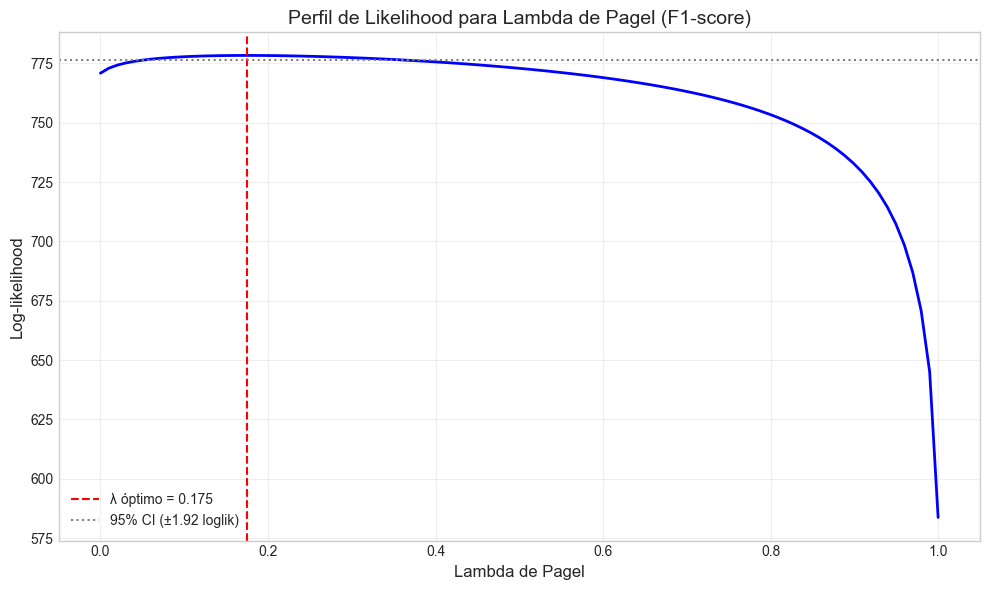

In [20]:
# Visualizar perfil de likelihood para lambda
if len(f1_scores) >= 10 and 'lambda_result' in dir():
    lambda_values = np.linspace(0, 1, 100)
    vcv_norm = vcv_matrix / vcv_matrix.max() if vcv_matrix.max() > 0 else vcv_matrix
    ll_values = [-pagel_lambda_likelihood(lam, f1_scores, vcv_norm) for lam in lambda_values]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(lambda_values, ll_values, 'b-', linewidth=2)
    ax.axvline(lambda_result['lambda'], color='r', linestyle='--', 
               label=f'λ óptimo = {lambda_result["lambda"]:.3f}')
    ax.axhline(lambda_result['loglik'] - 1.92, color='gray', linestyle=':', 
               label='95% CI (±1.92 loglik)')
    
    ax.set_xlabel('Lambda de Pagel', fontsize=12)
    ax.set_ylabel('Log-likelihood', fontsize=12)
    ax.set_title('Perfil de Likelihood para Lambda de Pagel (F1-score)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../fig/pgls_lambda_profile.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Saltando visualización de lambda - datos insuficientes o lambda no calculado")

## 5. Análisis PGLS

In [21]:
def fit_pgls(y, X, vcv, lambda_val=None):
    """
    Ajusta un modelo PGLS (Phylogenetic Generalized Least Squares).
    
    Si lambda_val es None, se estima por ML.
    Si lambda_val es un número, se usa ese valor fijo.
    """
    n = len(y)
    vcv_norm = vcv / vcv.max()
    
    # Estimar lambda si no se proporciona
    if lambda_val is None:
        def neg_ll(lam):
            V = lam * vcv_norm + (1 - lam) * np.eye(n)
            try:
                model = GLS(y, X, sigma=V)
                result = model.fit()
                return -result.llf
            except:
                return np.inf
        
        opt = minimize_scalar(neg_ll, bounds=(0, 1), method='bounded')
        lambda_val = opt.x
    
    # Ajustar modelo con lambda óptimo
    V_lambda = lambda_val * vcv_norm + (1 - lambda_val) * np.eye(n)
    
    model = GLS(y, X, sigma=V_lambda)
    result = model.fit()
    result.lambda_val = lambda_val
    
    return result

def fit_ols(y, X):
    """
    Ajusta un modelo OLS (sin corrección filogenética).
    """
    model = OLS(y, X)
    result = model.fit()
    return result

In [22]:
# Preparar datos para modelos
# Eliminar filas con valores faltantes en variables de interés
model_vars = morpho_available + geo_available
model_df = merged_df[['tree_name', 'f1-score', 'f1_logit', 'support', 'log_support'] + model_vars + eco_available].dropna()

print(f"Especies con datos completos: {len(model_df)}")

# Obtener índices de especies en la matriz VCV
model_species = model_df['tree_name'].tolist()

# Filtrar model_df a especies que están en vcv_taxa
model_df = model_df[model_df['tree_name'].isin(vcv_taxa)]
model_species = model_df['tree_name'].tolist()

# Obtener índices en el orden correcto
model_idx = [vcv_taxa_idx[sp] for sp in model_species if sp in vcv_taxa_idx]

if len(model_idx) == 0:
    print("⚠️  No hay especies en común entre el modelo y la matriz VCV")
    print(f"    Especies en model_df: {model_species[:5]}...")
    print(f"    Especies en VCV: {list(vcv_taxa_idx.keys())[:5]}...")
else:
    vcv_subset = vcv_matrix[np.ix_(model_idx, model_idx)]
    print(f"Matriz VCV para modelos: {vcv_subset.shape}")

Especies con datos completos: 583
Matriz VCV para modelos: (583, 583)


In [23]:
# Variables respuesta
y = model_df['f1-score'].values           # F1 original
y_logit = model_df['f1_logit'].values     # F1 transformado (logit)

# Covariable support
support = model_df['log_support'].values

# Matriz de diseño nula
X_null = np.ones((len(y), 1))

# Matriz con support
X_support = sm.add_constant(support)

# Almacenar resultados de modelos
model_results = {}

print(f"n = {len(y)} especies")
print(f"F1 original: media = {y.mean():.4f}, SD = {y.std():.4f}")
print(f"logit(F1): media = {y_logit.mean():.4f}, SD = {y_logit.std():.4f}")
print(f"log(support): media = {support.mean():.4f}, SD = {support.std():.4f}")

n = 583 especies
F1 original: media = 0.8569, SD = 0.0649
logit(F1): media = 1.8992, SD = 0.5930
log(support): media = 1.6307, SD = 0.2298


In [24]:
# Modelo 1: OLS nulo - Comparación F1 original vs logit(F1)
print("="*60)
print("MODELO 1: OLS Nulo (solo intercepto)")
print("="*60)

# F1 original
ols_null = fit_ols(y, X_null[:, :1])
model_results['OLS_null_F1'] = ols_null
print(f"\n  F1 original:")
print(f"    AIC: {ols_null.aic:.2f}")
print(f"    BIC: {ols_null.bic:.2f}")

# logit(F1)
ols_null_logit = fit_ols(y_logit, X_null[:, :1])
model_results['OLS_null_logit'] = ols_null_logit
print(f"\n  logit(F1):")
print(f"    AIC: {ols_null_logit.aic:.2f}")
print(f"    BIC: {ols_null_logit.bic:.2f}")

MODELO 1: OLS Nulo (solo intercepto)

  F1 original:
    AIC: -1532.94
    BIC: -1528.57

  logit(F1):
    AIC: 1047.09
    BIC: 1051.46


In [25]:
# Modelo 2: PGLS nulo - Comparación F1 original vs logit(F1)
print("\n" + "="*60)
print("MODELO 2: PGLS Nulo (solo intercepto)")
print("="*60)

# F1 original
pgls_null = fit_pgls(y, X_null[:, :1], vcv_subset)
model_results['PGLS_null_F1'] = pgls_null
print(f"\n  F1 original:")
print(f"    Lambda: {pgls_null.lambda_val:.4f}")
print(f"    AIC: {pgls_null.aic:.2f}")

# logit(F1)
pgls_null_logit = fit_pgls(y_logit, X_null[:, :1], vcv_subset)
model_results['PGLS_null_logit'] = pgls_null_logit
print(f"\n  logit(F1):")
print(f"    Lambda: {pgls_null_logit.lambda_val:.4f}")
print(f"    AIC: {pgls_null_logit.aic:.2f}")

# PGLS con Support (usando logit)
print("\n" + "="*60)
print("MODELO 2b: PGLS con Support (logit F1)")
print("="*60)
pgls_support = fit_pgls(y_logit, X_support, vcv_subset)
model_results['PGLS_support_logit'] = pgls_support
print(f"  Lambda: {pgls_support.lambda_val:.4f}")
print(f"  AIC: {pgls_support.aic:.2f}")
print(f"  R² ajustado: {pgls_support.rsquared_adj:.4f}")
print(f"\n  Coeficientes:")
print(f"    Intercepto: {pgls_support.params[0]:.4f} (p={pgls_support.pvalues[0]:.4f})")
print(f"    log(support): {pgls_support.params[1]:.4f} (p={pgls_support.pvalues[1]:.4f})")


MODELO 2: PGLS Nulo (solo intercepto)

  F1 original:
    Lambda: 0.1721
    AIC: -1546.90

  logit(F1):
    Lambda: 0.2030
    AIC: 1036.80

MODELO 2b: PGLS con Support (logit F1)
  Lambda: 0.1692
  AIC: 1036.14
  R² ajustado: 0.0030

  Coeficientes:
    Intercepto: 1.6577 (p=0.0000)
    log(support): 0.1797 (p=0.0976)


In [26]:
# Modelo 3: PGLS Morfológico (logit F1 + support)
# Log-transformar Mass y Range.Size para normalizar
model_df_log = model_df.copy()
if 'Mass' in model_df_log.columns:
    model_df_log['log_Mass'] = np.log10(model_df_log['Mass'] + 1)
if 'Range.Size' in model_df_log.columns:
    model_df_log['log_Range.Size'] = np.log10(model_df_log['Range.Size'] + 1)

# Variables morfológicas para el modelo
morpho_model_vars = []
for v in morpho_available:
    if v == 'Mass' and 'log_Mass' in model_df_log.columns:
        morpho_model_vars.append('log_Mass')
    else:
        morpho_model_vars.append(v)

morpho_model_vars = [v for v in morpho_model_vars if v in model_df_log.columns]

if len(morpho_model_vars) > 0:
    # Incluir support como primera covariable
    X_morpho = np.column_stack([
        np.ones(len(y_logit)),
        model_df_log['log_support'].values,
        model_df_log[morpho_model_vars].values
    ])
    pgls_morpho = fit_pgls(y_logit, X_morpho, vcv_subset)
    model_results['PGLS_morpho_logit'] = pgls_morpho

    print("\n" + "="*60)
    print("MODELO 3: PGLS Morfológico (logit F1 + support)")
    print("="*60)
    print(f"  Variables: ['log_support'] + {morpho_model_vars}")
    print(f"  Lambda: {pgls_morpho.lambda_val:.4f}")
    print(f"  AIC: {pgls_morpho.aic:.2f}")
    print(f"  R² ajustado: {pgls_morpho.rsquared_adj:.4f}")
    print(f"\n  Coeficientes:")
    var_names = ['const', 'log_support'] + morpho_model_vars
    for i, var in enumerate(var_names):
        if i < len(pgls_morpho.params):
            coef = pgls_morpho.params[i]
            pval = pgls_morpho.pvalues[i]
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            print(f"    {var}: {coef:.4f} (p={pval:.4f}) {sig}")
else:
    print("No hay variables morfológicas disponibles")


MODELO 3: PGLS Morfológico (logit F1 + support)
  Variables: ['log_support'] + ['log_Mass', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Tail.Length', 'Hand-Wing.Index']
  Lambda: 0.1120
  AIC: 1048.48
  R² ajustado: -0.0016

  Coeficientes:
    const: 1.5191 (p=0.0000) ***
    log_support: 0.1808 (p=0.1006) 
    log_Mass: 0.0387 (p=0.8557) 
    Beak.Length_Culmen: 0.0011 (p=0.9413) 
    Beak.Length_Nares: -0.0066 (p=0.6878) 
    Beak.Width: 0.0090 (p=0.7445) 
    Beak.Depth: 0.0150 (p=0.4806) 
    Tarsus.Length: 0.0063 (p=0.3368) 
    Wing.Length: -0.0008 (p=0.7104) 
    Tail.Length: -0.0020 (p=0.1551) 
    Hand-Wing.Index: 0.0018 (p=0.7278) 


In [27]:
# Modelo 4: PGLS Ecológico (logit F1 + support)
# Crear dummies para variables categóricas
eco_dummies = pd.get_dummies(model_df_log[eco_available], drop_first=True, dtype=float)

if len(eco_dummies.columns) > 0:
    X_eco = np.column_stack([
        np.ones(len(y_logit)),
        model_df_log['log_support'].values,
        eco_dummies.values
    ])
    pgls_eco = fit_pgls(y_logit, X_eco, vcv_subset)
    model_results['PGLS_eco_logit'] = pgls_eco

    print("\n" + "="*60)
    print("MODELO 4: PGLS Ecológico (logit F1 + support)")
    print("="*60)
    print(f"  Variables: ['log_support'] + {list(eco_dummies.columns)[:5]}...")
    print(f"  Lambda: {pgls_eco.lambda_val:.4f}")
    print(f"  AIC: {pgls_eco.aic:.2f}")
    print(f"  R² ajustado: {pgls_eco.rsquared_adj:.4f}")


MODELO 4: PGLS Ecológico (logit F1 + support)
  Variables: ['log_support'] + ['Habitat_Grassland', 'Habitat_Human Modified', 'Habitat_Riverine', 'Habitat_Rock', 'Habitat_Shrubland']...
  Lambda: 0.1190
  AIC: 1051.79
  R² ajustado: 0.0058


In [28]:
# Modelo 5: PGLS Geográfico (logit F1 + support)
geo_model_vars = []
for v in geo_available:
    if v == 'Range.Size' and 'log_Range.Size' in model_df_log.columns:
        geo_model_vars.append('log_Range.Size')
    else:
        geo_model_vars.append(v)

geo_model_vars = [v for v in geo_model_vars if v in model_df_log.columns]

if len(geo_model_vars) > 0:
    X_geo = np.column_stack([
        np.ones(len(y_logit)),
        model_df_log['log_support'].values,
        model_df_log[geo_model_vars].values
    ])
    pgls_geo = fit_pgls(y_logit, X_geo, vcv_subset)
    model_results['PGLS_geo_logit'] = pgls_geo

    print("\n" + "="*60)
    print("MODELO 5: PGLS Geográfico (logit F1 + support)")
    print("="*60)
    print(f"  Variables: ['log_support'] + {geo_model_vars}")
    print(f"  Lambda: {pgls_geo.lambda_val:.4f}")
    print(f"  AIC: {pgls_geo.aic:.2f}")
    print(f"  R² ajustado: {pgls_geo.rsquared_adj:.4f}")
    print(f"\n  Coeficientes:")
    var_names = ['const', 'log_support'] + geo_model_vars
    for i, var in enumerate(var_names):
        if i < len(pgls_geo.params):
            coef = pgls_geo.params[i]
            pval = pgls_geo.pvalues[i]
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            print(f"    {var}: {coef:.4f} (p={pval:.4f}) {sig}")


MODELO 5: PGLS Geográfico (logit F1 + support)
  Variables: ['log_support'] + ['log_Range.Size', 'Centroid.Latitude', 'Centroid.Longitude']
  Lambda: 0.1023
  AIC: 1017.49
  R² ajustado: 0.0409

  Coeficientes:
    const: 2.4392 (p=0.0000) ***
    log_support: 0.3963 (p=0.0007) ***
    log_Range.Size: -0.1571 (p=0.0000) ***
    Centroid.Latitude: 0.0030 (p=0.0977) 
    Centroid.Longitude: 0.0029 (p=0.0894) 


In [29]:
# Modelo 6: PGLS Completo (logit F1 + support + morfológico + ecológico + geográfico)
all_num_vars = morpho_model_vars + geo_model_vars
X_full_num = model_df_log[all_num_vars].values if all_num_vars else np.array([]).reshape(len(y_logit), 0)
X_full = np.column_stack([
    np.ones(len(y_logit)),
    model_df_log['log_support'].values,
    X_full_num,
    eco_dummies.values
])

pgls_full = fit_pgls(y_logit, X_full, vcv_subset)
model_results['PGLS_full_logit'] = pgls_full

print("\n" + "="*60)
print("MODELO 6: PGLS Completo (logit F1 + support)")
print("="*60)
print(f"  Lambda: {pgls_full.lambda_val:.4f}")
print(f"  AIC: {pgls_full.aic:.2f}")
print(f"  R² ajustado: {pgls_full.rsquared_adj:.4f}")
print(f"  Número de predictores: {X_full.shape[1] - 1}")

print(f"\n  Coeficientes significativos (p < 0.05):")
all_var_names = ['const', 'log_support'] + all_num_vars + list(eco_dummies.columns)
for i, var in enumerate(all_var_names):
    if i < len(pgls_full.params):
        coef = pgls_full.params[i]
        pval = pgls_full.pvalues[i]
        if pval < 0.05:
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
            print(f"    {var}: {coef:.4f} (p={pval:.4f}) {sig}")


MODELO 6: PGLS Completo (logit F1 + support)
  Lambda: 0.0000
  AIC: 1048.58
  R² ajustado: 0.0463
  Número de predictores: 30

  Coeficientes significativos (p < 0.05):
    const: 2.5622 (p=0.0000) ***
    log_support: 0.3849 (p=0.0016) **
    log_Range.Size: -0.1555 (p=0.0000) ***
    Trophic.Niche_Vertivore: 1.0105 (p=0.0148) *


In [30]:
# Comparación de modelos por AIC (solo modelos Logit)
print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS (solo modelos con logit F1)")
print("="*80)

# Filtrar solo modelos que usan logit (excluir F1 original)
comparison_data = []
for name, res in model_results.items():
    # Solo incluir modelos con transformación logit
    if name.endswith('_F1'):
        continue  # Excluir modelos con F1 original
    
    comparison_data.append({
        'Modelo': name,
        'AIC': res.aic,
        'BIC': res.bic,
        'Log-lik': res.llf,
        'Lambda': f"{res.lambda_val:.3f}" if hasattr(res, 'lambda_val') else 'N/A',
        'R² adj': f"{res.rsquared_adj:.4f}" if hasattr(res, 'rsquared_adj') else 'N/A',
        'n_params': len(res.params)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('AIC')
comparison_df['ΔAIC'] = comparison_df['AIC'] - comparison_df['AIC'].min()

print(comparison_df.to_string(index=False))

best_model = comparison_df.iloc[0]['Modelo']
print(f"\n→ Mejor modelo por AIC: {best_model}")

# Guardar comparación
comparison_df.to_csv('../src/data/pgls_model_comparison.csv', index=False)


COMPARACIÓN DE MODELOS (solo modelos con logit F1)
            Modelo         AIC         BIC     Log-lik Lambda  R² adj  n_params      ΔAIC
    PGLS_geo_logit 1017.489373 1039.330309 -503.744687  0.102  0.0409         5  0.000000
PGLS_support_logit 1036.144056 1044.880430 -516.072028  0.169  0.0030         2 18.654682
   PGLS_null_logit 1036.801818 1041.170006 -517.400909  0.203 -0.0000         1 19.312445
    OLS_null_logit 1047.087955 1051.456142 -522.543977    N/A  0.0000         1 29.598582
 PGLS_morpho_logit 1048.476689 1096.526748 -513.238345  0.112 -0.0016        11 30.987316
   PGLS_full_logit 1048.575814 1183.989617 -493.287907  0.000  0.0463        31 31.086441
    PGLS_eco_logit 1051.785137 1134.780694 -506.892569  0.119  0.0058        19 34.295764

→ Mejor modelo por AIC: PGLS_geo_logit


## 6. Importancia de Variables

In [31]:
# Calcular coeficientes estandarizados para el modelo completo (logit)
# beta_std = beta * (sd_x / sd_y)
all_var_names = ['const', 'log_support'] + morpho_model_vars + geo_model_vars + list(eco_dummies.columns)
all_num_vars_full = ['log_support'] + morpho_model_vars + geo_model_vars

importance_data = []
for i, var in enumerate(all_var_names):
    if i >= len(pgls_full.params):
        break
    
    coef = pgls_full.params[i]
    pval = pgls_full.pvalues[i]
    
    # Para variables numéricas, estandarizar
    if var in all_num_vars_full and var in model_df_log.columns:
        sd_x = np.std(model_df_log[var].values)
        sd_y = np.std(y_logit)
        std_coef = coef * sd_x / sd_y if sd_y > 0 else coef
    else:
        sd_y = np.std(y_logit)
        std_coef = coef / sd_y if sd_y > 0 else coef
    
    importance_data.append({
        'Variable': var,
        'Coef': coef,
        'Std_Coef': std_coef,
        'Abs_Std_Coef': abs(std_coef),
        'p_value': pval,
        'Significativo': pval < 0.05
    })

importance_df = pd.DataFrame(importance_data)
importance_df = importance_df.sort_values('Abs_Std_Coef', ascending=False)

print("IMPORTANCIA DE VARIABLES (Modelo PGLS Completo - logit F1)")
print("="*60)
print(importance_df[['Variable', 'Std_Coef', 'p_value', 'Significativo']].to_string(index=False))

# Guardar
importance_df.to_csv('../src/data/pgls_variable_importance.csv', index=False)

IMPORTANCIA DE VARIABLES (Modelo PGLS Completo - logit F1)
                     Variable  Std_Coef      p_value  Significativo
                        const  4.321078 1.438714e-08           True
      Trophic.Niche_Vertivore  1.704195 1.475544e-02           True
                 Habitat_Rock  0.575989 4.140225e-01          False
              Habitat_Wetland -0.486568 2.836206e-01          False
Primary.Lifestyle_Insessorial -0.479552 2.416778e-01          False
    Trophic.Niche_Invertivore  0.432194 6.581919e-02          False
      Trophic.Level_Herbivore  0.416896 9.471014e-02          False
 Primary.Lifestyle_Generalist -0.381586 3.943141e-01          False
               log_Range.Size -0.233525 1.812439e-05           True
    Trophic.Niche_Nectarivore  0.213772 6.543353e-01          False
             Habitat_Riverine -0.213458 7.298836e-01          False
                   Beak.Width  0.207619 7.686652e-02          False
      Trophic.Niche_Granivore -0.206385 4.341738e-01     

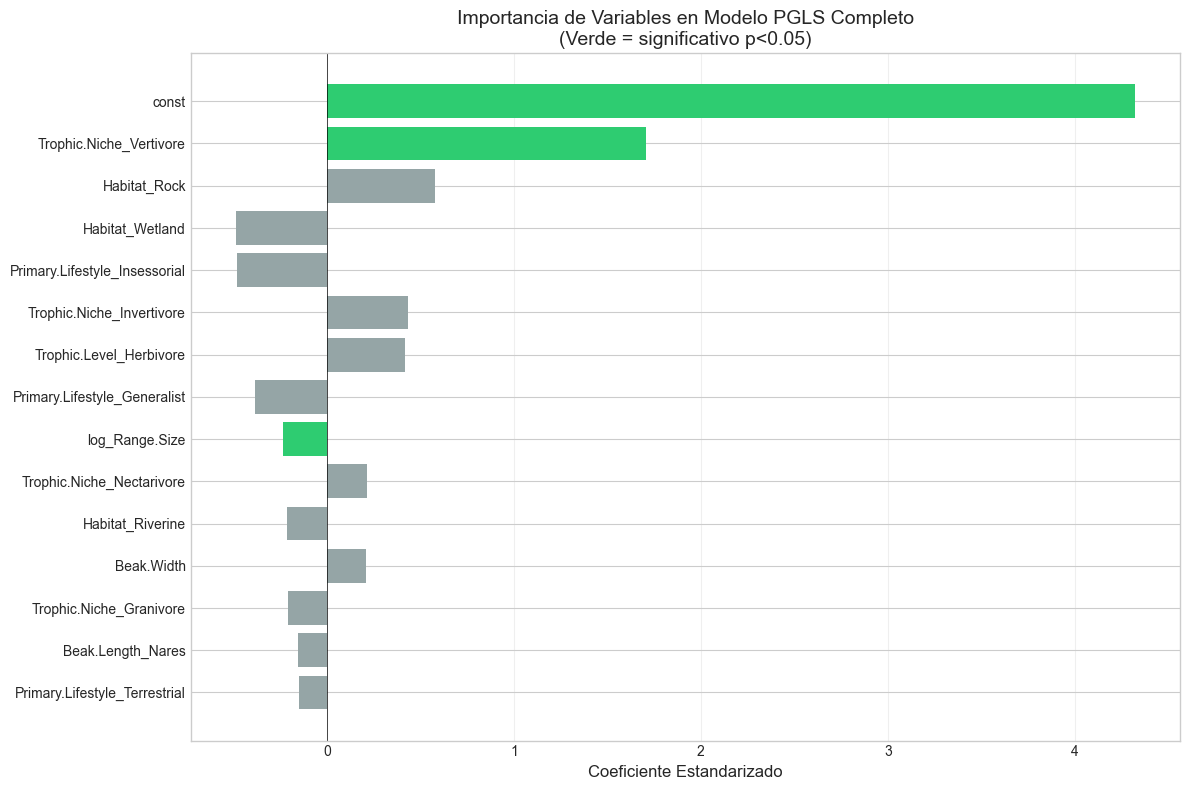

In [32]:
# Visualización de importancia de variables
fig, ax = plt.subplots(figsize=(12, 8))

# Solo mostrar top 15 variables
top_vars = importance_df.head(15)

colors = ['#2ecc71' if sig else '#95a5a6' for sig in top_vars['Significativo']]
bars = ax.barh(range(len(top_vars)), top_vars['Std_Coef'], color=colors)

ax.set_yticks(range(len(top_vars)))
ax.set_yticklabels(top_vars['Variable'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coeficiente Estandarizado', fontsize=12)
ax.set_title('Importancia de Variables en Modelo PGLS Completo\n(Verde = significativo p<0.05)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../fig/pgls_variable_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualizaciones

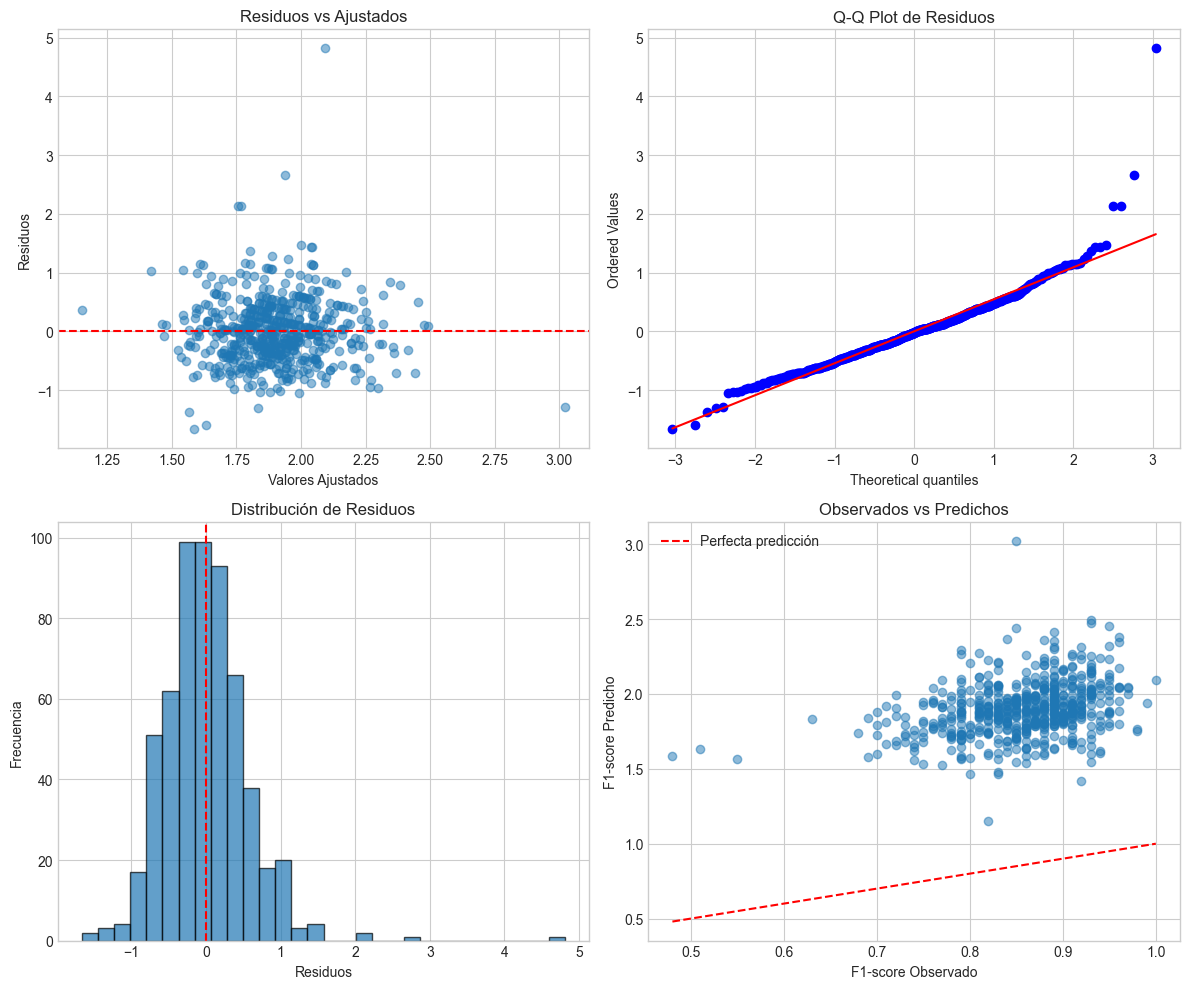

In [33]:
# Diagnósticos del mejor modelo PGLS
best_result = model_results.get('PGLS_full', pgls_full)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuos vs Ajustados
ax1 = axes[0, 0]
ax1.scatter(best_result.fittedvalues, best_result.resid, alpha=0.5)
ax1.axhline(0, color='r', linestyle='--')
ax1.set_xlabel('Valores Ajustados')
ax1.set_ylabel('Residuos')
ax1.set_title('Residuos vs Ajustados')

# 2. Q-Q Plot
ax2 = axes[0, 1]
stats.probplot(best_result.resid, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot de Residuos')

# 3. Histograma de residuos
ax3 = axes[1, 0]
ax3.hist(best_result.resid, bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(0, color='r', linestyle='--')
ax3.set_xlabel('Residuos')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Residuos')

# 4. Observados vs Predichos
ax4 = axes[1, 1]
ax4.scatter(y, best_result.fittedvalues, alpha=0.5)
ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfecta predicción')
ax4.set_xlabel('F1-score Observado')
ax4.set_ylabel('F1-score Predicho')
ax4.set_title('Observados vs Predichos')
ax4.legend()

plt.tight_layout()
plt.savefig('../fig/pgls_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

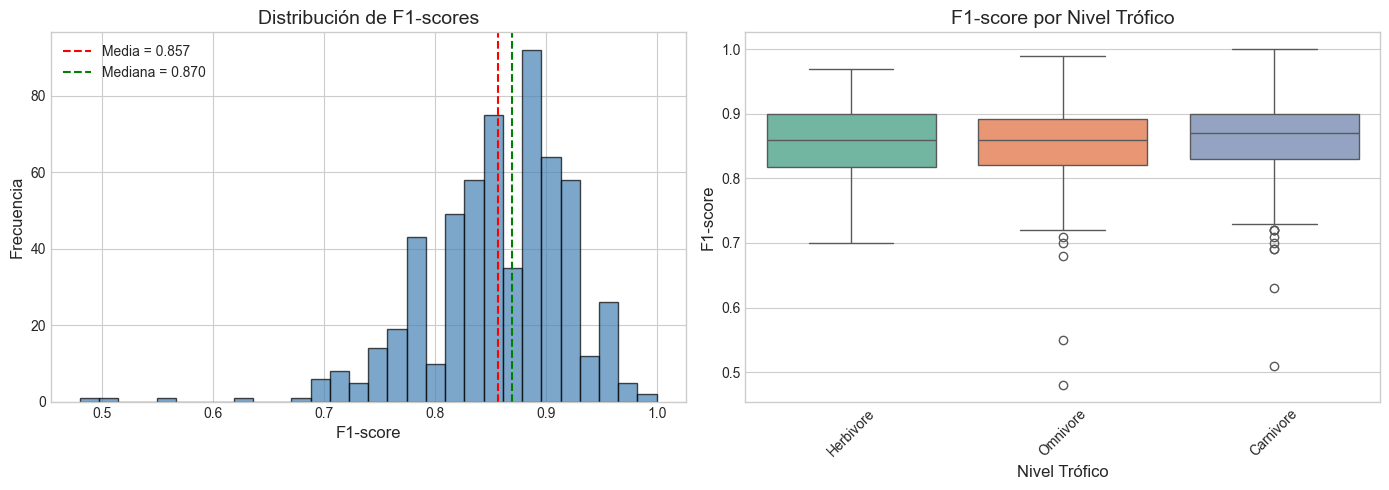

In [34]:
# Distribución de F1-scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de F1-scores
ax1 = axes[0]
ax1.hist(f1_scores, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(f1_scores.mean(), color='r', linestyle='--', label=f'Media = {f1_scores.mean():.3f}')
ax1.axvline(np.median(f1_scores), color='g', linestyle='--', label=f'Mediana = {np.median(f1_scores):.3f}')
ax1.set_xlabel('F1-score', fontsize=12)
ax1.set_ylabel('Frecuencia', fontsize=12)
ax1.set_title('Distribución de F1-scores', fontsize=14)
ax1.legend()

# Boxplot por categoría ecológica (si disponible)
ax2 = axes[1]
if 'Trophic.Level' in model_df.columns:
    trophic_data = model_df[['f1-score', 'Trophic.Level']].dropna()
    trophic_order = trophic_data.groupby('Trophic.Level')['f1-score'].median().sort_values().index
    sns.boxplot(data=trophic_data, x='Trophic.Level', y='f1-score', 
                order=trophic_order, ax=ax2, palette='Set2')
    ax2.set_xlabel('Nivel Trófico', fontsize=12)
    ax2.set_ylabel('F1-score', fontsize=12)
    ax2.set_title('F1-score por Nivel Trófico', fontsize=14)
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../fig/pgls_f1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Identificar especies con rendimiento atípico (residuos extremos)
residuals = best_result.resid
residual_std = (residuals - residuals.mean()) / residuals.std()

model_df_results = model_df.copy()
model_df_results['residual'] = residuals
model_df_results['residual_std'] = residual_std
model_df_results['predicted'] = best_result.fittedvalues

# Especies que sobre-rinden (residuos positivos altos)
over_performers = model_df_results[model_df_results['residual_std'] > 2].sort_values('residual_std', ascending=False)

# Especies que sub-rinden (residuos negativos altos)
under_performers = model_df_results[model_df_results['residual_std'] < -2].sort_values('residual_std')

print("ESPECIES CON RENDIMIENTO ATÍPICO")
print("="*60)
print(f"\nSobre-rinden (residuo std > 2): {len(over_performers)} especies")
if len(over_performers) > 0:
    print(over_performers[['tree_name', 'f1-score', 'predicted', 'residual_std']].head(10).to_string(index=False))

print(f"\nSub-rinden (residuo std < -2): {len(under_performers)} especies")
if len(under_performers) > 0:
    print(under_performers[['tree_name', 'f1-score', 'predicted', 'residual_std']].head(10).to_string(index=False))

ESPECIES CON RENDIMIENTO ATÍPICO

Sobre-rinden (residuo std > 2): 17 especies
                tree_name  f1-score  predicted  residual_std
    Myiornis_atricapillus      1.00   2.091858      8.538054
Sericossypha_albocristata      0.99   1.938781      4.710373
         Neoctantes_niger      0.98   1.754152      3.790636
    Automolus_melanopezus      0.98   1.765973      3.769674
        Euphonia_concinna      0.97   1.999441      2.618493
  Sclerurus_guatemalensis      0.97   2.038100      2.549941
     Hylopezus_macularius      0.97   2.043576      2.540230
     Automolus_infuscatus      0.96   1.802748      2.438771
      Synallaxis_cherriei      0.96   1.889313      2.285268
   Myiotheretes_fumigatus      0.96   1.950818      2.176204

Sub-rinden (residuo std < -2): 5 especies
              tree_name  f1-score  predicted  residual_std
      Lipaugus_unirufus      0.48   1.584247     -2.951220
        Nemosia_pileata      0.51   1.634147     -2.826828
   Molothrus_oryzivorus      0.

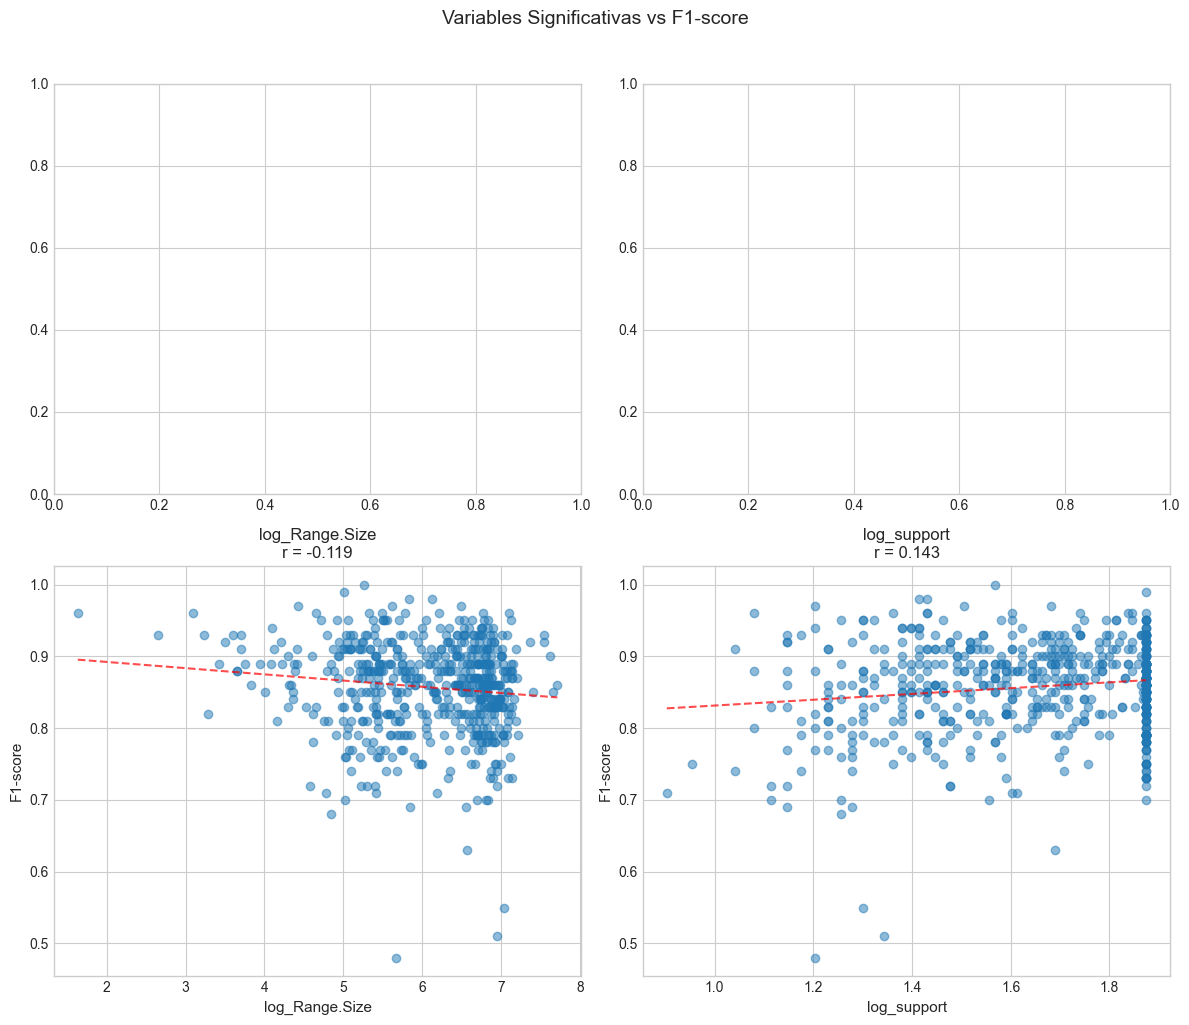

In [36]:
# Scatter plots de variables más importantes vs F1-score
sig_vars = importance_df[importance_df['Significativo']]['Variable'].tolist()[:4]

if len(sig_vars) > 0:
    n_plots = min(4, len(sig_vars))
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, var in enumerate(sig_vars[:n_plots]):
        ax = axes[i]
        if var in model_df_log.columns:
            ax.scatter(model_df_log[var], y, alpha=0.5)
            ax.set_xlabel(var, fontsize=11)
            ax.set_ylabel('F1-score', fontsize=11)
            
            # Añadir línea de tendencia
            z = np.polyfit(model_df_log[var].dropna(), 
                          y[~model_df_log[var].isna()], 1)
            p = np.poly1d(z)
            x_line = np.linspace(model_df_log[var].min(), model_df_log[var].max(), 100)
            ax.plot(x_line, p(x_line), 'r--', alpha=0.7)
            
            # Correlación
            corr = model_df_log[var].corr(pd.Series(y, index=model_df_log.index))
            ax.set_title(f'{var}\nr = {corr:.3f}', fontsize=12)
    
    # Ocultar ejes vacíos
    for j in range(n_plots, 4):
        axes[j].set_visible(False)
    
    plt.suptitle('Variables Significativas vs F1-score', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('../fig/pgls_significant_vars.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontraron variables significativas para graficar.")

## 7b. Análisis de Confusión Filogenética

**Pregunta clave**: ¿Las especies que se confunden entre sí son filogenéticamente cercanas?

Si la respuesta es sí, sugiere que la similitud vocal está relacionada con la filogenia.

In [37]:
# Cargar tabla de confusiones
confusion_df = pd.read_csv('../src/data/tabla_confusiones_analisis.csv')
print(f"Tabla de confusiones cargada: {confusion_df.shape[0]} especies")

# Filtrar especies con confusión identificada
confusion_analysis = confusion_df[confusion_df['Principal Confusión'] != 'N/A'].copy()
confusion_analysis['species_std'] = confusion_analysis['Especie'].str.replace(' ', '_')
confusion_analysis['confusion_std'] = confusion_analysis['Principal Confusión'].str.replace(' ', '_')

print(f"Pares de confusión a analizar: {len(confusion_analysis)}")

Tabla de confusiones cargada: 667 especies
Pares de confusión a analizar: 667


In [38]:
# Función para calcular distancia filogenética
def get_phylo_distance(tree, sp1, sp2):
    """Calcula la distancia filogenética entre dos especies."""
    try:
        if USE_ETE3:
            node1 = tree.search_nodes(name=sp1)
            node2 = tree.search_nodes(name=sp2)
            if node1 and node2:
                return tree.get_distance(node1[0], node2[0])
        else:
            terminals = {t.name: t for t in tree.get_terminals()}
            if sp1 in terminals and sp2 in terminals:
                return tree.distance(terminals[sp1], terminals[sp2])
    except:
        pass
    return np.nan

# Calcular distancias para pares de confusión
print("Calculando distancias filogenéticas entre pares de confusión...")

confusion_distances = []
for _, row in confusion_analysis.iterrows():
    sp1 = row['species_std']
    sp2 = row['confusion_std']
    
    # Buscar en árbol
    sp1_tree = species_tree_mapping.get(sp1, sp1)
    sp2_tree = species_tree_mapping.get(sp2, sp2)
    
    dist = get_phylo_distance(pruned_tree, sp1_tree, sp2_tree)
    
    # Verificar si son de la misma familia
    fam1 = avonet_df[avonet_df['species_std'] == sp1]['Family3'].values
    fam2 = avonet_df[avonet_df['species_std'] == sp2]['Family3'].values
    same_fam = fam1[0] == fam2[0] if len(fam1) > 0 and len(fam2) > 0 else np.nan
    
    confusion_distances.append({
        'species': sp1,
        'confused_with': sp2,
        'phylo_distance': dist,
        'same_family': same_fam,
        'accuracy': row['Acc. (%)'],
        'f1_score': row['F1-Score']
    })

confusion_dist_df = pd.DataFrame(confusion_distances)
print(f"Pares con distancia calculada: {confusion_dist_df['phylo_distance'].notna().sum()}")

Calculando distancias filogenéticas entre pares de confusión...
Pares con distancia calculada: 524


In [39]:
# Generar distribución nula (pares aleatorios)
print("Generando distribución nula de distancias aleatorias...")

n_random = 1000
random_distances = []
available_species = list(set(pruned_species))

np.random.seed(42)
for _ in range(n_random):
    sp1, sp2 = np.random.choice(available_species, 2, replace=False)
    dist = get_phylo_distance(pruned_tree, sp1, sp2)
    if not np.isnan(dist):
        random_distances.append(dist)

random_distances = np.array(random_distances)
print(f"Distancias aleatorias calculadas: {len(random_distances)}")

Generando distribución nula de distancias aleatorias...
Distancias aleatorias calculadas: 1000


In [40]:
# Comparación estadística
observed_distances = confusion_dist_df['phylo_distance'].dropna().values

print("="*60)
print("ANÁLISIS DE DISTANCIA FILOGENÉTICA EN CONFUSIONES")
print("="*60)

print(f"\nDistancia filogenética de pares CONFUNDIDOS:")
print(f"  Media: {np.mean(observed_distances):.4f}")
print(f"  Mediana: {np.median(observed_distances):.4f}")
print(f"  n = {len(observed_distances)}")

print(f"\nDistancia filogenética de pares ALEATORIOS:")
print(f"  Media: {np.mean(random_distances):.4f}")
print(f"  Mediana: {np.median(random_distances):.4f}")
print(f"  n = {len(random_distances)}")

# Test de Mann-Whitney U (unilateral: confundidos < aleatorios)
stat_mw, p_mw = stats.mannwhitneyu(observed_distances, random_distances, alternative='less')
print(f"\nTest Mann-Whitney U (H₀: confundidos ≥ aleatorios):")
print(f"  U = {stat_mw:.2f}")
print(f"  p-value (unilateral) = {p_mw:.6f}")

if p_mw < 0.05:
    print(f"\n→ CONCLUSIÓN: Las especies confundidas están SIGNIFICATIVAMENTE")
    print(f"  más cercanas filogenéticamente que lo esperado por azar.")
else:
    print(f"\n→ CONCLUSIÓN: NO hay evidencia de que las especies confundidas")
    print(f"  estén más cercanas filogenéticamente.")

# Proporción misma familia
same_fam_counts = confusion_dist_df['same_family'].value_counts()
n_with_fam = confusion_dist_df['same_family'].notna().sum()
prop_same_family = same_fam_counts.get(True, 0) / n_with_fam if n_with_fam > 0 else 0

print(f"\nCONFUSIONES POR FAMILIA:")
print(f"  Misma familia: {same_fam_counts.get(True, 0)} ({prop_same_family:.1%})")
print(f"  Diferente familia: {same_fam_counts.get(False, 0)}")

ANÁLISIS DE DISTANCIA FILOGENÉTICA EN CONFUSIONES

Distancia filogenética de pares CONFUNDIDOS:
  Media: 57.1075
  Mediana: 61.2483
  n = 524

Distancia filogenética de pares ALEATORIOS:
  Media: 66.7826
  Mediana: 72.4169
  n = 1000

Test Mann-Whitney U (H₀: confundidos ≥ aleatorios):
  U = 214268.50
  p-value (unilateral) = 0.000000

→ CONCLUSIÓN: Las especies confundidas están SIGNIFICATIVAMENTE
  más cercanas filogenéticamente que lo esperado por azar.

CONFUSIONES POR FAMILIA:
  Misma familia: 131 (25.1%)
  Diferente familia: 391


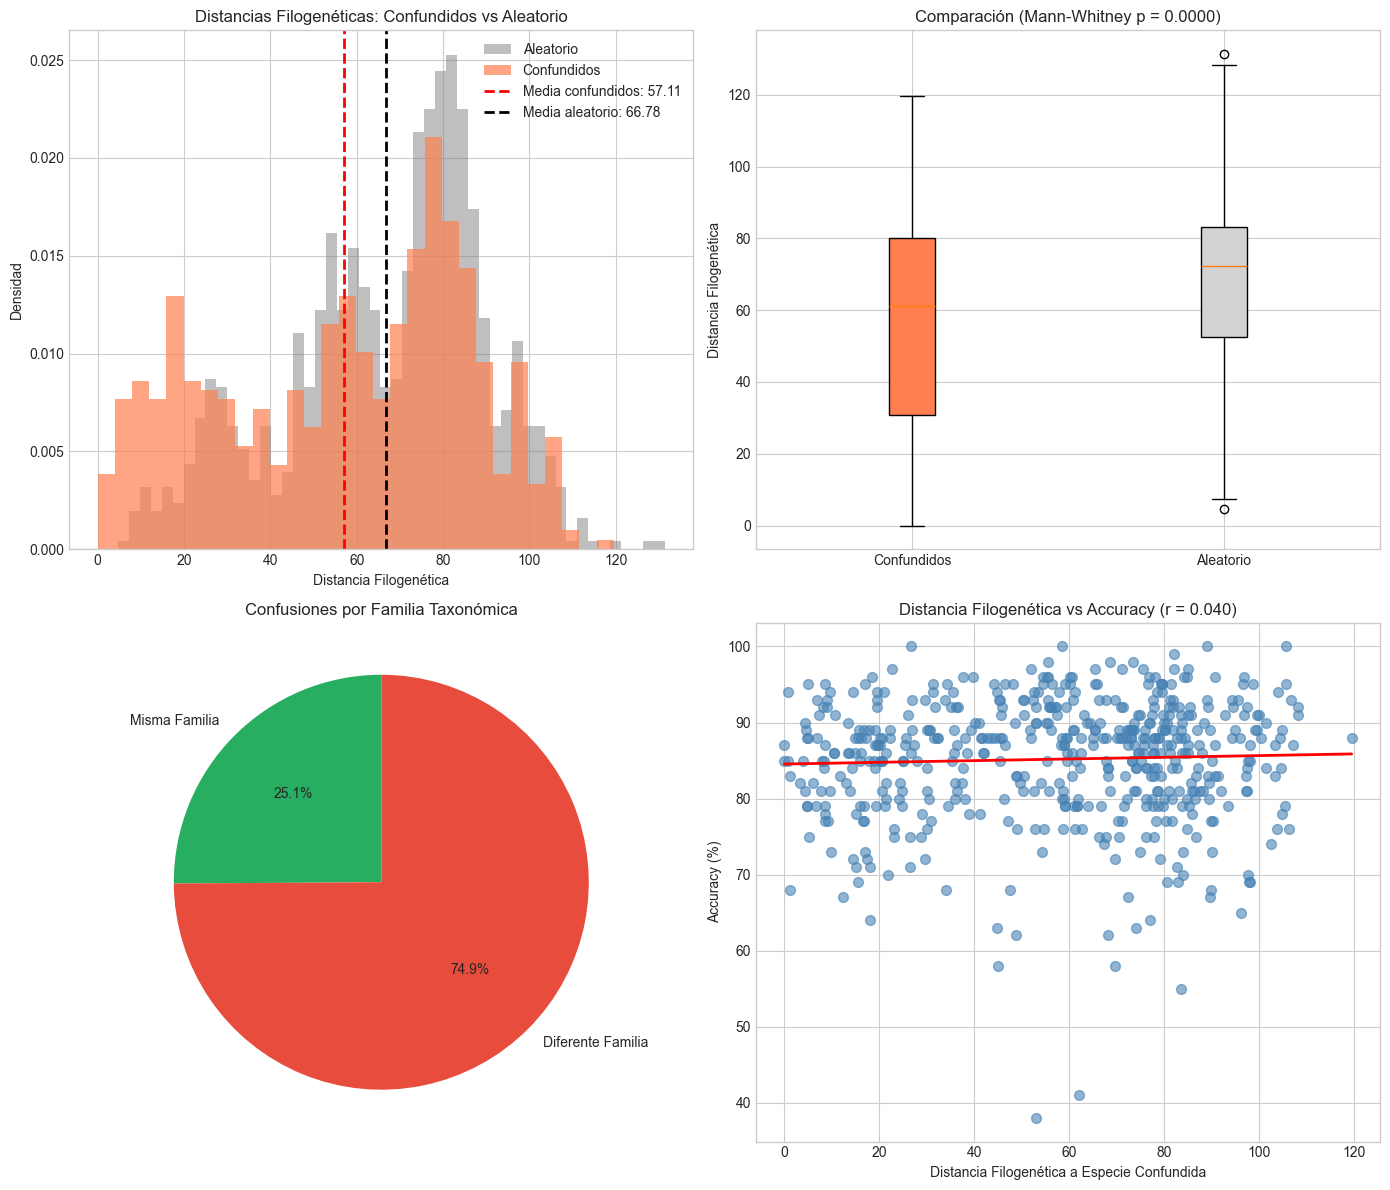

In [41]:
# Visualización del análisis de confusión
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Histograma comparativo
ax1 = axes[0, 0]
ax1.hist(random_distances, bins=50, alpha=0.5, label='Aleatorio', color='gray', density=True)
ax1.hist(observed_distances, bins=30, alpha=0.7, label='Confundidos', color='coral', density=True)
ax1.axvline(np.mean(observed_distances), color='red', linestyle='--', linewidth=2,
            label=f'Media confundidos: {np.mean(observed_distances):.2f}')
ax1.axvline(np.mean(random_distances), color='black', linestyle='--', linewidth=2,
            label=f'Media aleatorio: {np.mean(random_distances):.2f}')
ax1.set_xlabel('Distancia Filogenética')
ax1.set_ylabel('Densidad')
ax1.set_title('Distancias Filogenéticas: Confundidos vs Aleatorio')
ax1.legend()

# 2. Boxplot
ax2 = axes[0, 1]
bp = ax2.boxplot([observed_distances, random_distances], labels=['Confundidos', 'Aleatorio'], patch_artist=True)
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('lightgray')
ax2.set_ylabel('Distancia Filogenética')
ax2.set_title(f'Comparación (Mann-Whitney p = {p_mw:.4f})')

# 3. Pie chart familias
ax3 = axes[1, 0]
family_counts = [same_fam_counts.get(True, 0), same_fam_counts.get(False, 0)]
ax3.pie(family_counts, labels=['Misma Familia', 'Diferente Familia'],
        autopct='%1.1f%%', colors=['#27ae60', '#e74c3c'], startangle=90)
ax3.set_title('Confusiones por Familia Taxonómica')

# 4. Distancia vs Accuracy
ax4 = axes[1, 1]
valid_idx = confusion_dist_df['phylo_distance'].notna()
ax4.scatter(confusion_dist_df.loc[valid_idx, 'phylo_distance'],
            confusion_dist_df.loc[valid_idx, 'accuracy'], alpha=0.6, s=50, c='steelblue')
x_valid = confusion_dist_df.loc[valid_idx, 'phylo_distance'].values
y_valid = confusion_dist_df.loc[valid_idx, 'accuracy'].values
if len(x_valid) > 1:
    z = np.polyfit(x_valid, y_valid, 1)
    p_line = np.poly1d(z)
    ax4.plot(np.sort(x_valid), p_line(np.sort(x_valid)), color='red', linewidth=2)
    corr_dist_acc = np.corrcoef(x_valid, y_valid)[0, 1]
    ax4.set_title(f'Distancia Filogenética vs Accuracy (r = {corr_dist_acc:.3f})')
ax4.set_xlabel('Distancia Filogenética a Especie Confundida')
ax4.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.savefig('../fig/pgls_confusion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# Top confusiones más cercanas filogenéticamente
print("\n" + "="*60)
print("TOP 15 CONFUSIONES MÁS CERCANAS FILOGENÉTICAMENTE")
print("="*60)

closest = confusion_dist_df.dropna(subset=['phylo_distance']).nsmallest(15, 'phylo_distance')
print(closest[['species', 'confused_with', 'phylo_distance', 'same_family', 'accuracy']].to_string(index=False))

# Guardar análisis de confusión
confusion_dist_df.to_csv('../src/data/pgls_confusion_distances.csv', index=False)
print(f"\nGuardado: ../src/data/pgls_confusion_distances.csv")


TOP 15 CONFUSIONES MÁS CERCANAS FILOGENÉTICAMENTE
                  species              confused_with  phylo_distance same_family  accuracy
      Pyriglena_leuconota            Pyriglena_maura        0.000000         NaN      87.0
          Pyriglena_maura        Pyriglena_leuconota        0.000000         NaN      85.0
     Cercomacra_nigricans     Cercomacra_cinerascens        0.841027        True      94.0
   Cercomacra_cinerascens       Cercomacra_nigricans        0.841027        True      85.0
  Sporophila_caerulescens     Sporophila_nigricollis        1.120679        True      83.0
   Sporophila_nigricollis    Sporophila_caerulescens        1.120679        True      68.0
Lepidocolaptes_souleyetii  Lepidocolaptes_lacrymiger        3.321083        True      82.0
    Lophotriccus_vitiosus      Lophotriccus_galeatus        3.867942        True      85.0
            Daptrius_ater         Milvago_chimachima        4.345351        True      90.0
  Anisognathus_lacrymosus           Dub

## 8. Resumen y Conclusiones

In [43]:
print("="*70)
print("RESUMEN DEL ANÁLISIS PGLS MEJORADO")
print("="*70)

print("\n1. MEJORAS METODOLÓGICAS APLICADAS")
print("   - Transformación logit del F1-score (datos acotados → normalizados)")
print("   - Support (n muestras) incluido como covariable en todos los modelos")
print("   - Análisis de confusión filogenética")

print("\n2. SEÑAL FILOGENÉTICA")
if 'lambda_result' in dir():
    print(f"   λ de Pagel (logit F1): {lambda_result['lambda']:.4f}")
    if lambda_result['p_value'] < 0.05:
        print(f"   - Significativamente diferente de 0 (p = {lambda_result['p_value']:.4f})")
    if lambda_result['lambda'] > 0.5:
        interp = "FUERTE: La filogenia explica gran parte de la varianza"
    elif lambda_result['lambda'] > 0.1:
        interp = "MODERADA: La filogenia explica parte de la varianza"
    else:
        interp = "DÉBIL: La filogenia explica poca varianza"
    print(f"   - Interpretación: {interp}")

print("\n3. EFECTO DEL SUPPORT")
if 'pgls_support' in model_results:
    ps = model_results['PGLS_support_logit']
    print(f"   Coeficiente log(support): {ps.params[1]:.4f} (p = {ps.pvalues[1]:.4f})")
    if ps.pvalues[1] < 0.05:
        print("   → El tamaño de muestra afecta SIGNIFICATIVAMENTE el F1-score")

print("\n4. ANÁLISIS DE CONFUSIÓN FILOGENÉTICA")
if 'p_mw' in dir():
    print(f"   Distancia media confundidos: {np.mean(observed_distances):.4f}")
    print(f"   Distancia media aleatorio: {np.mean(random_distances):.4f}")
    print(f"   Test Mann-Whitney p = {p_mw:.6f}")
    if p_mw < 0.05:
        print("   → Las confusiones NO son aleatorias: especies cercanas se confunden más")

print("\n5. COMPARACIÓN DE MODELOS")
print(comparison_df[['Modelo', 'AIC', 'ΔAIC', 'R² adj']].to_string(index=False))

print("\n6. VARIABLES SIGNIFICATIVAS (p < 0.05)")
sig_only = importance_df[importance_df['Significativo']]
if len(sig_only) > 0:
    for _, row in sig_only.iterrows():
        direction = '↑' if row['Std_Coef'] > 0 else '↓'
        print(f"   - {row['Variable']}: β_std = {row['Std_Coef']:.4f} {direction} (p = {row['p_value']:.4f})")
else:
    print("   Ninguna variable fue significativa (p < 0.05)")

RESUMEN DEL ANÁLISIS PGLS MEJORADO

1. MEJORAS METODOLÓGICAS APLICADAS
   - Transformación logit del F1-score (datos acotados → normalizados)
   - Support (n muestras) incluido como covariable en todos los modelos
   - Análisis de confusión filogenética

2. SEÑAL FILOGENÉTICA
   λ de Pagel (logit F1): 0.1748
   - Significativamente diferente de 0 (p = 0.0001)
   - Interpretación: MODERADA: La filogenia explica parte de la varianza

3. EFECTO DEL SUPPORT

4. ANÁLISIS DE CONFUSIÓN FILOGENÉTICA
   Distancia media confundidos: 57.1075
   Distancia media aleatorio: 66.7826
   Test Mann-Whitney p = 0.000000
   → Las confusiones NO son aleatorias: especies cercanas se confunden más

5. COMPARACIÓN DE MODELOS
            Modelo         AIC      ΔAIC  R² adj
    PGLS_geo_logit 1017.489373  0.000000  0.0409
PGLS_support_logit 1036.144056 18.654682  0.0030
   PGLS_null_logit 1036.801818 19.312445 -0.0000
    OLS_null_logit 1047.087955 29.598582  0.0000
 PGLS_morpho_logit 1048.476689 30.987316 -0.

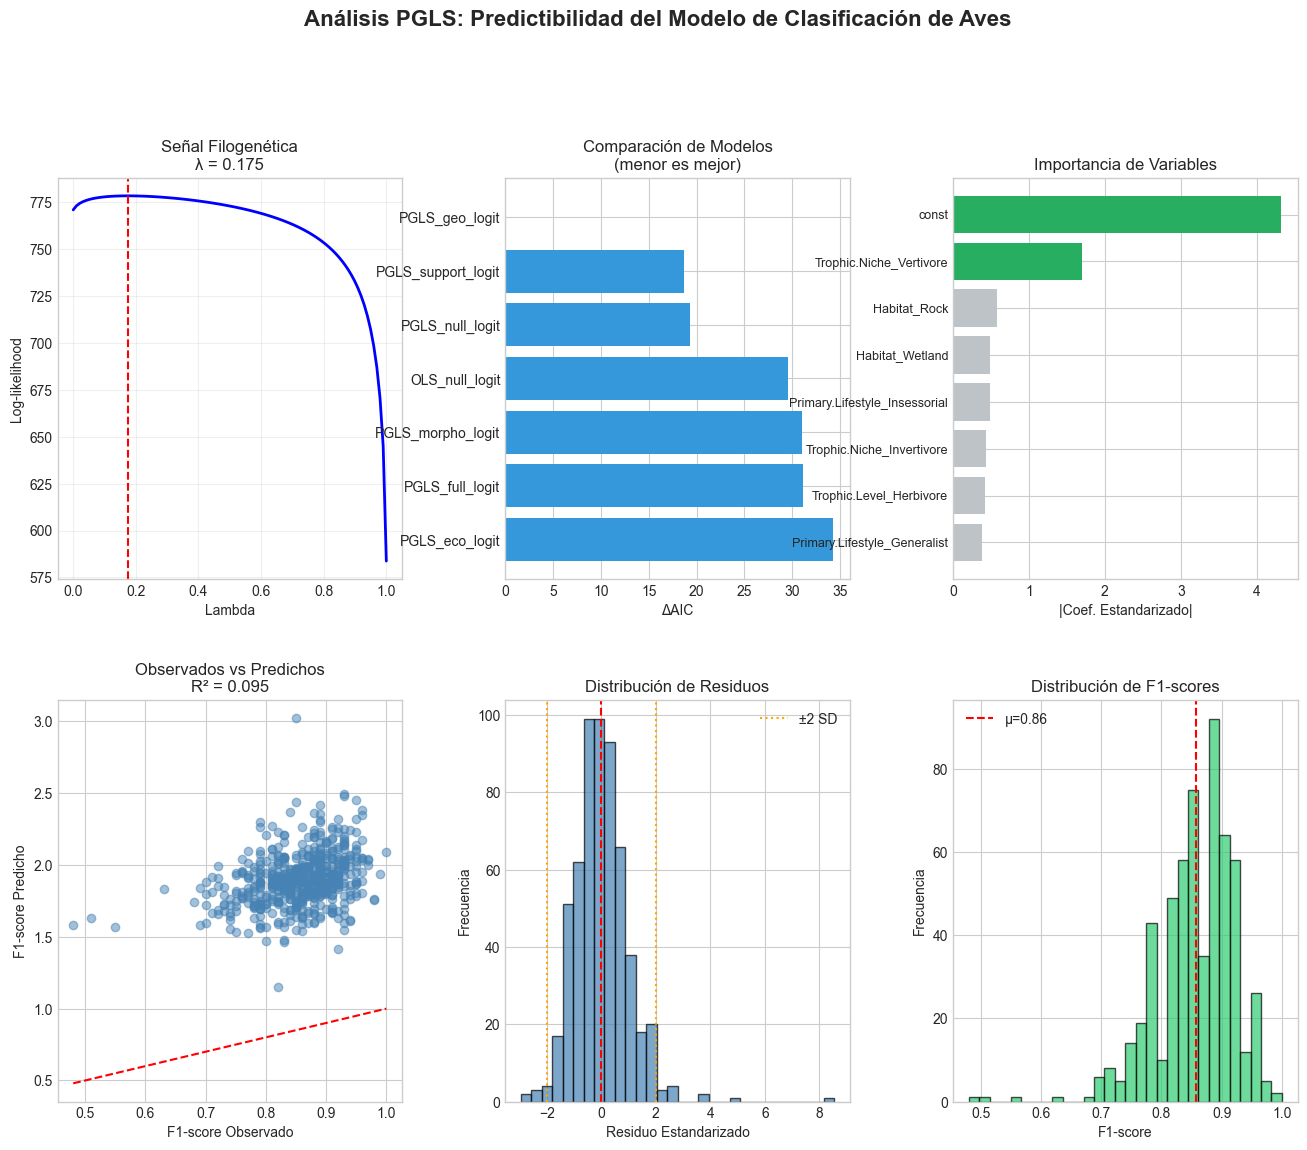

In [44]:
# Panel de resumen visual
fig = plt.figure(figsize=(16, 12))

# Layout: 2x3 grid
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Lambda profile
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(lambda_values, ll_values, 'b-', linewidth=2)
ax1.axvline(lambda_result['lambda'], color='r', linestyle='--')
ax1.set_xlabel('Lambda')
ax1.set_ylabel('Log-likelihood')
ax1.set_title(f'Señal Filogenética\nλ = {lambda_result["lambda"]:.3f}')
ax1.grid(True, alpha=0.3)

# 2. Comparación de modelos (AIC)
ax2 = fig.add_subplot(gs[0, 1])
models = comparison_df['Modelo'].values
aics = comparison_df['ΔAIC'].values
colors = ['#e74c3c' if aic == 0 else '#3498db' for aic in aics]
ax2.barh(models, aics, color=colors)
ax2.set_xlabel('ΔAIC')
ax2.set_title('Comparación de Modelos\n(menor es mejor)')
ax2.invert_yaxis()

# 3. Importancia de variables (top 8)
ax3 = fig.add_subplot(gs[0, 2])
top8 = importance_df.head(8)
colors = ['#27ae60' if sig else '#bdc3c7' for sig in top8['Significativo']]
ax3.barh(range(len(top8)), top8['Abs_Std_Coef'], color=colors)
ax3.set_yticks(range(len(top8)))
ax3.set_yticklabels(top8['Variable'], fontsize=9)
ax3.invert_yaxis()
ax3.set_xlabel('|Coef. Estandarizado|')
ax3.set_title('Importancia de Variables')

# 4. Observados vs Predichos
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y, best_result.fittedvalues, alpha=0.5, c='steelblue')
ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax4.set_xlabel('F1-score Observado')
ax4.set_ylabel('F1-score Predicho')
ax4.set_title(f'Observados vs Predichos\nR² = {best_result.rsquared:.3f}')

# 5. Distribución de residuos
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(residual_std, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax5.axvline(0, color='r', linestyle='--')
ax5.axvline(-2, color='orange', linestyle=':', label='±2 SD')
ax5.axvline(2, color='orange', linestyle=':')
ax5.set_xlabel('Residuo Estandarizado')
ax5.set_ylabel('Frecuencia')
ax5.set_title('Distribución de Residuos')
ax5.legend()

# 6. F1-score distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(f1_scores, bins=30, edgecolor='black', alpha=0.7, color='#2ecc71')
ax6.axvline(f1_scores.mean(), color='r', linestyle='--', label=f'μ={f1_scores.mean():.2f}')
ax6.set_xlabel('F1-score')
ax6.set_ylabel('Frecuencia')
ax6.set_title('Distribución de F1-scores')
ax6.legend()

plt.suptitle('Análisis PGLS: Predictibilidad del Modelo de Clasificación de Aves', 
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../fig/pgls_summary_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Guardar resultados
results_summary = {
    'n_species': len(model_df),
    'lambda_pagel': lambda_result['lambda'],
    'lambda_pvalue': lambda_result['p_value'],
    'blomberg_k': k_result['K'],
    'best_model': best_model,
    'best_model_aic': comparison_df.iloc[0]['AIC'],
    'best_model_r2': float(comparison_df.iloc[0]['R² adj'].replace('N/A', 'nan')),
    'n_significant_vars': len(sig_only),
    'n_over_performers': len(over_performers),
    'n_under_performers': len(under_performers)
}

# Guardar como CSV
model_df_results.to_csv('../src/data/pgls_species_results.csv', index=False)
importance_df.to_csv('../src/data/pgls_variable_importance.csv', index=False)
comparison_df.to_csv('../src/data/pgls_model_comparison.csv', index=False)

print("Resultados guardados en:")
print("  - ../src/data/pgls_species_results.csv")
print("  - ../src/data/pgls_variable_importance.csv")
print("  - ../src/data/pgls_model_comparison.csv")
print("\nFiguras guardadas en:")
print("  - ../fig/pgls_vcv_matrix.png")
print("  - ../fig/pgls_lambda_profile.png")
print("  - ../fig/pgls_variable_importance.png")
print("  - ../fig/pgls_diagnostics.png")
print("  - ../fig/pgls_f1_distribution.png")
print("  - ../fig/pgls_significant_vars.png")
print("  - ../fig/pgls_summary_panel.png")

Resultados guardados en:
  - ../src/data/pgls_species_results.csv
  - ../src/data/pgls_variable_importance.csv
  - ../src/data/pgls_model_comparison.csv

Figuras guardadas en:
  - ../fig/pgls_vcv_matrix.png
  - ../fig/pgls_lambda_profile.png
  - ../fig/pgls_variable_importance.png
  - ../fig/pgls_diagnostics.png
  - ../fig/pgls_f1_distribution.png
  - ../fig/pgls_significant_vars.png
  - ../fig/pgls_summary_panel.png


---

## Interpretación Biológica

### Señal Filogenética
- **Lambda alto (>0.5)**: Especies cercanamente relacionadas tienen F1-scores similares, sugiriendo que características heredadas (morfología, comportamiento, vocalización) influyen en la clasificabilidad.
- **Lambda bajo (<0.5)**: La predictibilidad del modelo está menos determinada por la filogenia, posiblemente influenciada más por factores ecológicos o ambientales.

### Variables Predictoras
- **Morfológicas**: Si variables como masa corporal o longitud de ala son significativas, sugiere que aves de ciertos tamaños/formas son más fáciles de clasificar acústicamente.
- **Ecológicas**: Variables como nivel trófico o hábitat pueden indicar que ciertos nichos ecológicos producen vocalizaciones más distintivas.
- **Geográficas**: El tamaño del rango o latitud pueden reflejar variabilidad intraespecífica en vocalizaciones.

### Especies Atípicas
- **Sobre-rinden**: Especies con F1-score mayor al esperado pueden tener vocalizaciones particularmente distintivas.
- **Sub-rinden**: Especies con F1-score menor al esperado pueden tener vocalizaciones similares a otras especies o alta variabilidad intraespecífica.